<a href="https://colab.research.google.com/github/vccf/Deep-Learning-Experiments/blob/working-demo-versions/TPH_YOLOv5Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I gonna use YOLOv5 and TPH-YOLOv5 to try to replicate and experiment on. The Dataset used will be VisDrone2019. In TPH-YOLOv5 article VisDrone2021 was used, but the article itself says it's the same dataset as VisDrone 2019. The goal of this notebook is to replicate the TPH-YOLOv5 article (within my limitations) and analyse it considering interpretability (using EigenCAM) and robustness (considering gaussian noise, blur, brightness and occlusion).

https://github.com/vccf/Deep-Learning-Experiments/

* https://github.com/ultralytics/yolov5
* https://github.com/cv516Buaa/tph-yolov5
* https://docs.ultralytics.com/yolov5/tutorials/train_custom_data
* https://docs.ultralytics.com/models/yolov5
* https://github.com/VisDrone/VisDrone-Dataset
* https://github.com/jacobgil/pytorch-grad-cam
* https://jacobgil.github.io/pytorch-gradcam-book/EigenCAM%20for%20YOLO5.html
* https://github.com/rigvedrs/YOLO-26-CAM


In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [2]:
!pip install grad-cam #for interpretability

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=b345ab0ad219e6af5c45c3b4f9218b4ff4a8491b3424fa8e3eabab1773e1159a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
!pip show grad-cam

Name: grad-cam
Version: 1.5.5
Summary: Many Class Activation Map methods implemented in Pytorch for classification, segmentation, object detection and more
Home-page: https://github.com/jacobgil/pytorch-grad-cam
Author: Jacob Gildenblat
Author-email: jacob.gildenblat@gmail.com
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, opencv-python, Pillow, scikit-learn, torch, torchvision, tqdm, ttach
Required-by: 


In [4]:
!git clone https://github.com/cv516Buaa/tph-yolov5.git

Cloning into 'tph-yolov5'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 246 (delta 106), reused 218 (delta 97), pack-reused 0 (from 0)
Receiving objects: 100% (246/246), 9.27 MiB | 24.22 MiB/s, done.
Resolving deltas: 100% (106/106), done.


In [5]:
%cd tph-yolov5

/content/tph-yolov5


In [ ]:
%%writefile tph_yolov5_colab_compat_patch.sh

#!/bin/bash
# tph_yolov5_colab_compat_patch.sh
#
# Run this ONCE, right after cloning tph-yolov5 and BEFORE `pip install -r
# requirements.txt`, in a fresh Colab runtime.
#
#   !git clone https://github.com/cv516Buaa/tph-yolov5
#   %cd tph-yolov5
#   !bash tph_yolov5_colab_compat_patch.sh
#
# Why this exists: tph-yolov5 hasn't been updated to track newer
# torch/numpy/Pillow/PyYAML releases. Colab ships current versions of all
# four, so several old API calls in the repo now raise errors or are
# outright removed. This script does NOT try to downgrade torch to match
# the repo's original 2021 environment -- Colab's current GPU/driver/CUDA
# stack generally won't have wheels for torch that old anymore, and forcing
# it would just trade one set of breakages for another. Instead it patches
# the handful of now-broken calls so the repo runs cleanly under modern
# library versions.

set -e
echo "=== tph-yolov5 Colab compatibility patch ==="

# ---------------------------------------------------------------------
# 1) numpy: np.int / np.float / np.bool / np.object were deprecated in
#    numpy 1.20 and REMOVED entirely in numpy>=1.24. Colab currently ships
#    numpy>=1.24 by default. Old yolov5-era code (utils/metrics.py,
#    utils/plots.py, utils/datasets.py / dataloaders.py) uses these
#    aliases in a few places -> AttributeError: module 'numpy' has no
#    attribute 'int'.
#    Fix: replace the deprecated aliases with the builtin types directly,
#    repo-wide.
# ---------------------------------------------------------------------
echo "[1/6] Patching deprecated numpy aliases (np.int/np.float/np.bool/np.object)..."
grep -rl --include="*.py" -E '\bnp\.(int|float|bool|object)\b' . 2>/dev/null | while read -r f; do
    sed -i -E \
        -e 's/\bnp\.int\b/int/g' \
        -e 's/\bnp\.float\b/float/g' \
        -e 's/\bnp\.bool\b/bool/g' \
        -e 's/\bnp\.object\b/object/g' \
        "$f"
done

# ---------------------------------------------------------------------
# 2) Pillow: Image.ANTIALIAS was removed in Pillow>=10 (it's been
#    Image.Resampling.LANCZOS since Pillow 9.1). Colab ships Pillow>=10.
#    -> AttributeError: module 'PIL.Image' has no attribute 'ANTIALIAS'.
# ---------------------------------------------------------------------
echo "[2/6] Patching PIL.Image.ANTIALIAS -> Image.Resampling.LANCZOS..."
grep -rl --include="*.py" 'ANTIALIAS' . 2>/dev/null | while read -r f; do
    sed -i 's/Image\.ANTIALIAS/Image.Resampling.LANCZOS/g' "$f"
done

# ---------------------------------------------------------------------
# 3) PyYAML: yaml.load(f) without an explicit Loader raises
#    "TypeError: load() missing 1 required positional argument: 'Loader'"
#    on PyYAML>=6 (unsafe implicit Loader was removed for security
#    reasons). Older repo code sometimes calls yaml.load(f) bare instead
#    of yaml.safe_load(f).
# ---------------------------------------------------------------------
echo "[3/6] Patching bare yaml.load() calls to yaml.safe_load()..."
grep -rl --include="*.py" -E 'yaml\.load\(([^,]*)\)' . 2>/dev/null | while read -r f; do
    sed -i -E 's/yaml\.load\(([^,)]*)\)/yaml.safe_load(\1)/g' "$f"
done

# ---------------------------------------------------------------------
# 4) torch.load: torch>=2.6 changed the default of `weights_only` from
#    False to True. Old checkpoints that pickle a full custom Model object
#    (rather than a plain state_dict) fail to unpickle under the new
#    default, or the class layout of torch.nn.modules.linear itself has
#    shifted between torch versions this repo's weights were saved with
#    vs. what Colab now ships -- this is the exact failure mode reported
#    in https://github.com/cv516Buaa/tph-yolov5/issues/19
#    ("Can't get attribute 'NonDynamicallyQuantizableLinear'").
#    Fix: force weights_only=False everywhere torch.load() is called in
#    this repo (safe here since these are your own trusted checkpoints,
#    not arbitrary downloaded files).
# ---------------------------------------------------------------------
echo "[4/6] Patching torch.load() calls to pass weights_only=False..."
grep -rl --include="*.py" -E 'torch\.load\(' . 2>/dev/null | while read -r f; do
    # only add weights_only=False if it isn't already specified
    grep -q 'weights_only' "$f" || \
    sed -i -E "s/torch\.load\(([^)]*)\)/torch.load(\1, weights_only=False)/g" "$f"
done

# ---------------------------------------------------------------------
# 5) collections.abc: Python's `collections.MutableMapping`-style direct
#    imports (as opposed to `collections.abc.MutableMapping`) were removed
#    in Python 3.10+. Colab now runs Python 3.11/3.12. This mostly affects
#    old *dependency* code more than yolov5 itself, but check just in case
#    a stray import slipped into utils/.
# ---------------------------------------------------------------------
echo "[5/6] Checking for legacy collections.* imports (informational only)..."
grep -rn --include="*.py" -E 'from collections import (Mapping|MutableMapping|Sequence|Iterable)\b' . 2>/dev/null \
    && echo "    ^ found legacy collections imports above -- these need manual fixing to collections.abc.X" \
    || echo "    none found"

# ---------------------------------------------------------------------
# 6) Package pins: install compatible versions BEFORE the repo's own
#    requirements.txt, so pip doesn't pull numpy>=1.24 or protobuf
#    versions that conflict with tensorboard logging.
#    NOTE: we deliberately do NOT pin torch/torchvision -- use whatever
#    Colab ships (it already matches the installed CUDA driver).
# ---------------------------------------------------------------------
echo "[6/6] Installing known-compatible auxiliary package versions..."
pip install -q "protobuf<=3.20.3" "PyYAML>=6.0" "Pillow>=10.3.0"

echo ""
echo "=== Patch complete ==="
echo "Now run: pip install -r requirements.txt --no-deps"
echo "(--no-deps avoids requirements.txt re-pulling an incompatible numpy/torch pin;"
echo " install any genuinely missing packages afterward one at a time if import errors remain)"

In [6]:
!bash tph_yolov5_colab_compat_patch.sh
!pip install -r requirements.txt --no-deps

tph_yolov5_colab_compat_patch.sh: line 20: $'\r': command not found
: invalid option
set: usage: set [-abefhkmnptuvxBCHP] [-o option-name] [--] [arg ...]
=== tph-yolov5 Colab compatibility patch ===
tph_yolov5_colab_compat_patch.sh: line 23: $'\r': command not found
[1/6] Patching deprecated numpy aliases (np.int/np.float/np.bool/np.object)...
tph_yolov5_colab_compat_patch.sh: line 95: syntax error near unexpected token `&&'
'


In [7]:
#!python detect.py --weights yolov5l.pt --source data/images

In [7]:
%cd ..

/content


In [8]:
%mkdir datasets

In [9]:
%cd datasets/

/content/datasets


In [10]:
%mkdir VisDrone

In [11]:
%cd VisDrone/

/content/datasets/VisDrone


In [12]:
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-dev.zip
!wget https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-test-challenge.zip

--2026-07-05 15:39:21--  https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/9137a849-834e-4c54-b2d5-14d12384f10f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-05T16%3A19%3A56Z&rscd=attachment%3B+filename%3DVisDrone2019-DET-train.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-05T15%3A19%3A09Z&ske=2026-07-05T16%3A19%3A56Z&sks=b&skv=2018-11-09&sig=Q4bJNvXI9HLy3KkxxKIhW7JTTX6exPSoaqtjCaeMa%2B8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MzI2OTU2MSwibmJmIjoxNzgzMjY1OTYxLCJwYXRoIjoicmVsZWFzZWF

In [13]:
!unzip VisDrone2019-DET-train.zip
!unzip VisDrone2019-DET-val.zip
!unzip VisDrone2019-DET-test-dev.zip
!unzip VisDrone2019-DET-test-challenge.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: VisDrone2019-DET-val/images/0000291_03801_d_0000887.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_04001_d_0000888.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_04201_d_0000889.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_04401_d_0000890.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_05001_d_0000892.jpg  
  inflating: VisDrone2019-DET-val/images/0000291_05201_d_0000893.jpg  
  inflating: VisDrone2019-DET-val/images/0000293_03601_d_0000940.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00000_d_0000021.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00200_d_0000022.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00600_d_0000024.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_00800_d_0000025.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_01000_d_0000026.jpg  
  inflating: VisDrone2019-DET-val/images/0000295_01200_d_0000027.jpg  
  inflating: VisDr

In [14]:
!ls

VisDrone2019-DET-test-challenge      VisDrone2019-DET-train
VisDrone2019-DET-test-challenge.zip  VisDrone2019-DET-train.zip
VisDrone2019-DET-test-dev	     VisDrone2019-DET-val
VisDrone2019-DET-test-dev.zip	     VisDrone2019-DET-val.zip


In [15]:
%cd /content/datasets/VisDrone/VisDrone2019-DET-train

/content/datasets/VisDrone/VisDrone2019-DET-train


In [16]:
!ls

annotations  images


In [17]:
%cd /content/datasets/VisDrone/VisDrone2019-DET-val

/content/datasets/VisDrone/VisDrone2019-DET-val


In [18]:
!ls

annotations  images


In [19]:
%cd /content/datasets/VisDrone/VisDrone2019-DET-test-dev/

/content/datasets/VisDrone/VisDrone2019-DET-test-dev


In [20]:
!ls

annotations  images


In [21]:
%cd /content/datasets/VisDrone

/content/datasets/VisDrone


In [22]:
%mkdir -p /content/datasets/VisDrone/images/train
%mkdir -p /content/datasets/VisDrone/images/val
%mkdir -p /content/datasets/VisDrone/images/test
%mkdir -p /content/datasets/VisDrone/labels/train
%mkdir -p /content/datasets/VisDrone/labels/val
%mkdir -p /content/datasets/VisDrone/labels/test

In [23]:
%cp /content/datasets/VisDrone/VisDrone2019-DET-train/images/* \
   /content/datasets/VisDrone/images/train/

%cp /content/datasets/VisDrone/VisDrone2019-DET-val/images/* \
   /content/datasets/VisDrone/images/val/

%cp /content/datasets/VisDrone/VisDrone2019-DET-test-dev/images/* \
   /content/datasets/VisDrone/images/test/

In [24]:
%%writefile /content/tph-yolov5/data/visdrone.yaml

path: /content/datasets/VisDrone

train: images/train
val: images/val
test : images/test

nc: 10

names:
  [
    0: pedestrian,
    1: people,
    2: bicycle,
    3: car,
    4: van,
    5: truck,
    6: tricycle,
    7: awning-tricycle,
    8: bus,
    9: motor
  ]

Writing /content/tph-yolov5/data/visdrone.yaml


In [25]:
import os
import cv2

def convert_visdrone(ann_dir, img_dir, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    files = [f for f in os.listdir(ann_dir) if f.endswith(".txt")]

    for ann_file in files:

        img_file = ann_file.replace(".txt", ".jpg")
        img_path = os.path.join(img_dir, img_file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]

        yolo_lines = []

        with open(os.path.join(ann_dir, ann_file)) as f:
            for line in f:

                parts = line.strip().split(",")

                if len(parts) < 8:
                    continue

                x = float(parts[0])
                y = float(parts[1])
                bw = float(parts[2])
                bh = float(parts[3])
                cls = int(parts[5])

                # ignore ignored regions
                if cls == 0:
                    continue

                xc = (x + bw/2) / w
                yc = (y + bh/2) / h

                bw /= w
                bh /= h

                yolo_cls = cls - 1

                yolo_lines.append(
                    f"{yolo_cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
                )

        with open(os.path.join(save_dir, ann_file), "w") as out:
            out.write("\n".join(yolo_lines))

In [26]:
convert_visdrone(
    "/content/datasets/VisDrone/VisDrone2019-DET-train/annotations",
    "/content/datasets/VisDrone/VisDrone2019-DET-train/images",
    "/content/datasets/VisDrone/labels/train"
)

convert_visdrone(
    "/content/datasets/VisDrone/VisDrone2019-DET-val/annotations",
    "/content/datasets/VisDrone/VisDrone2019-DET-val/images",
    "/content/datasets/VisDrone/labels/val"
)

convert_visdrone(
    "/content/datasets/VisDrone/VisDrone2019-DET-test-dev/annotations",
    "/content/datasets/VisDrone/VisDrone2019-DET-test-dev/images",
    "/content/datasets/VisDrone/labels/test"
)

In [27]:
!head -5 /content/datasets/VisDrone/labels/train/9999999_00879_d_0000403.txt

3 0.356000 0.907667 0.059000 0.174000
0 0.368750 0.774333 0.016500 0.038000
0 0.385500 0.638667 0.013000 0.034667
3 0.363500 0.609000 0.035000 0.083333
3 0.366000 0.533000 0.031000 0.074000


In [28]:
!find /content/datasets/VisDrone -name "*.cache" -delete

In [29]:
!find /content/datasets/VisDrone/images/train -name "*.jpg" | wc -l
!find /content/datasets/VisDrone/labels/train -name "*.txt" | wc -l

6471
6471


In [30]:
!ls /content/datasets/VisDrone/labels/train | head

0000002_00005_d_0000014.txt
0000002_00448_d_0000015.txt
0000003_00231_d_0000016.txt
0000007_04999_d_0000036.txt
0000007_05499_d_0000037.txt
0000007_05999_d_0000038.txt
0000008_00889_d_0000039.txt
0000008_01999_d_0000040.txt
0000008_02499_d_0000041.txt
0000008_02999_d_0000042.txt


In [31]:
!find /content/datasets/VisDrone/images/train -name "*.jpg" | wc -l
!find /content/datasets/VisDrone/labels/train -name "*.txt" | wc -l

!find /content/datasets/VisDrone/images/val -name "*.jpg" | wc -l
!find /content/datasets/VisDrone/labels/val -name "*.txt" | wc -l

6471
6471
548
548


In [32]:
!grep -R "," /content/datasets/VisDrone/labels/train | head
!grep -R "," /content/datasets/VisDrone/labels/val | head

In [33]:
!grep -R "^10 " /content/datasets/VisDrone/labels/train | head

/content/datasets/VisDrone/labels/train/9999942_00000_d_0000146.txt:10 0.522500 0.881905 0.012143 0.024762
/content/datasets/VisDrone/labels/train/9999942_00000_d_0000146.txt:10 0.536429 0.881429 0.017143 0.018095
/content/datasets/VisDrone/labels/train/9999942_00000_d_0000146.txt:10 0.485714 0.740476 0.011429 0.025714
/content/datasets/VisDrone/labels/train/9999942_00000_d_0000146.txt:10 0.504643 0.702857 0.013571 0.024762
/content/datasets/VisDrone/labels/train/9999942_00000_d_0000146.txt:10 0.470000 0.624286 0.012857 0.029524
/content/datasets/VisDrone/labels/train/9999942_00000_d_0000146.txt:10 0.497500 0.509048 0.010714 0.020000
/content/datasets/VisDrone/labels/train/9999955_00000_d_0000410.txt:10 0.053214 0.636421 0.049286 0.046954
/content/datasets/VisDrone/labels/train/9999948_00000_d_0000030.txt:10 0.118929 0.381429 0.110714 0.092381
/content/datasets/VisDrone/labels/train/9999955_00000_d_0000238.txt:10 0.256786 0.645305 0.027857 0.049492
/content/datasets/VisDrone/labels/tra

In [34]:
!awk '{print $1}' /content/datasets/VisDrone/labels/train/*.txt | sort -n | tail

10
10
10
10
10
10
10
10
10
10


In [35]:
from pathlib import Path

for folder in [
    "/content/datasets/VisDrone/labels/train",
    "/content/datasets/VisDrone/labels/val",
    "/content/datasets/VisDrone/labels/test"
]:
    for f in Path(folder).glob("*.txt"):
        with open(f) as infile:
            lines = infile.readlines()

        lines = [line for line in lines if not line.startswith("10 ")]

        with open(f, "w") as outfile:
            outfile.writelines(lines)

print("Done")

Done


In [36]:
!awk '{print $1}' /content/datasets/VisDrone/labels/train/*.txt | sort -n | tail

9
9
9
9
9
9
9
9
9
9


In [37]:
!find /content/datasets/VisDrone -name "*.cache" -delete

train.py line 118

ckpt = torch.load(weights, map_location=device)

Replace it with:

ckpt = torch.load(weights, map_location=device, weights_only=False)

train.py add

from numpy import random, interp

In [41]:
!grep -rn "np.int" .

./train.py:305:                # compute_loss.gr = np.interp(ni, xi, [0.0, 1.0])  # iou loss ratio (obj_loss = 1.0 or iou)
./train.py:306:                accumulate = max(1, np.interp(ni, xi, [1, nbs / batch_size]).round())
./train.py:309:                    x['lr'] = np.interp(ni, xi, [hyp['warmup_bias_lr'] if j == 2 else 0.0, x['initial_lr'] * lf(epoch)])
./train.py:311:                        x['momentum'] = np.interp(ni, xi, [hyp['warmup_momentum'], hyp['momentum']])
./utils/augmentations.py:227:                cv2.drawContours(im_new, [segments[j].astype(np.int32)], -1, (255, 255, 255), cv2.FILLED)
./utils/datasets.py:441:        bi = np.floor(np.arange(n) / batch_size).astype(np.int)  # batch index
./utils/datasets.py:483:            self.batch_shapes = np.ceil(np.array(shapes) * img_size / stride + pad).astype(np.int) * stride
./utils/datasets.py:853:                    b = xywh2xyxy(b.reshape(-1, 4)).ravel().astype(np.int)
./utils/metrics.py:60:            r[ci] = np.interp(-px

In [43]:
!find . -name "*.py" -exec sed -i 's/np\.int/int/g' {} +

In [44]:
!grep -rn "np.int" .

./tph_yolov5_colab_compat_patch.sh:25:# 1) numpy: np.int / np.float / np.bool / np.object were deprecated in
./tph_yolov5_colab_compat_patch.sh:34:echo "[1/6] Patching deprecated numpy aliases (np.int/np.float/np.bool/np.object)..."


In [47]:
from pathlib import Path
import re

ROOT = Path("/content/tph-yolov5")

patched = []

for f in ROOT.rglob("*.py"):
    text = f.read_text(encoding="utf-8")
    original = text

    # ---------------------------------------------------------
    # NumPy 2.x compatibility
    # ---------------------------------------------------------
    replacements = {
        "np.int": "int",
        "np.float": "float",
        "np.bool": "bool",
        "np.object": "object",
        "np.str": "str",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)

    # ---------------------------------------------------------
    # torch.load() (PyTorch 2.6)
    # ---------------------------------------------------------
    def repl(m):
        args = m.group(1)
        if "weights_only=" in args:
            return m.group(0)
        return f"torch.load({args}, weights_only=False)"

    text = re.sub(
        r"torch\.load\(([^()\n]*)\)",
        repl,
        text
    )

    # ---------------------------------------------------------
    # Missing interp import
    # ---------------------------------------------------------
    if "interp(" in text and "from numpy import interp" not in text:
        if "from numpy import random" in text:
            text = text.replace(
                "from numpy import random",
                "from numpy import random, interp"
            )
        elif "import numpy as np" in text:
            text = text.replace(
                "import numpy as np",
                "import numpy as np\nfrom numpy import interp"
            )

    # ---------------------------------------------------------
    # clamp_ compatibility (PyTorch >=2)
    # ---------------------------------------------------------
    text = text.replace(
        "gj.clamp_(0, gain[3] - 1)",
        "gj.clamp_(0, int(gain[3].item()) - 1)"
    )

    text = text.replace(
        "gi.clamp_(0, gain[2] - 1)",
        "gi.clamp_(0, int(gain[2].item()) - 1)"
    )

    # ---------------------------------------------------------
    # torch.meshgrid compatibility
    # ---------------------------------------------------------
    text = re.sub(
        r"torch\.meshgrid\(([^)]*)\)",
        r"torch.meshgrid(\1, indexing='ij')",
        text
    )

    # ---------------------------------------------------------
    # Remove deprecated np.int dtype declarations
    # ---------------------------------------------------------
    text = text.replace("dtype=np.int", "dtype=int")

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------
    if text != original:
        f.write_text(text, encoding="utf-8")
        patched.append(str(f.relative_to(ROOT)))

print(f"Patched {len(patched)} files:")
for p in patched:
    print(" -", p)

Patched 13 files:
 - detect.py
 - models/tf.py
 - models/yolo.py
 - models/common.py
 - utils/augmentations.py
 - utils/datasets.py
 - utils/loss.py
 - utils/metrics.py
 - utils/metrics_aIoU.py
 - utils/plots.py
 - utils/general.py
 - utils/loggers/__init__.py
 - utils/aws/resume.py


In [49]:
import re
from pathlib import Path

path = Path("models/common.py")
content = path.read_text()

# Collapse any duplicated indexing= kwarg down to a single one
fixed = re.sub(
    r'indexing=["\']ij["\'],\s*indexing=["\']ij["\']',
    'indexing="ij"',
    content
)

if fixed != content:
    path.write_text(fixed)
    print("Patched duplicate `indexing=` kwarg in models/common.py")
else:
    print("No match found — check the exact text around line 259 and paste it here")

Patched duplicate `indexing=` kwarg in models/common.py


In [50]:
!python -c "from models.common import Conv; print('common.py imports OK')"

common.py imports OK


In [52]:
# repair_stripped_np_prefix.py
# Run from inside tph-yolov5/, in a fresh cell:  !python repair_stripped_np_prefix.py
#
# Fixes cases where "np." got accidentally stripped from numpy dtype names
# like np.float64, np.int64, np.int32, np.float32, np.uint8, np.bool_ --
# leaving a bare, undefined name (e.g. "dtype=float64" -> NameError).
# Only touches these specific known dtype tokens, and only when they are
# NOT already preceded by "np." -- so it won't double-prefix anything.

import re
from pathlib import Path

DTYPE_NAMES = ["float64", "float32", "int64", "int32", "uint8", "bool_"]

pattern = re.compile(
    r'(?<!np\.)(?<!\w)(' + '|'.join(DTYPE_NAMES) + r')\b'
)

fixed_files = []
for path in Path(".").rglob("*.py"):
    text = path.read_text()
    new_text = pattern.sub(r'np.\1', text)
    if new_text != text:
        path.write_text(new_text)
        fixed_files.append(str(path))

if fixed_files:
    print("Restored missing `np.` prefix in:")
    for f in fixed_files:
        print(" -", f)
else:
    print("No bare dtype names found -- issue may be elsewhere, paste the new traceback if it recurs.")

Restored missing `np.` prefix in:
 - export.py
 - detect.py
 - train.py
 - val.py
 - models/tf.py
 - models/common.py
 - utils/autoanchor.py
 - utils/augmentations.py
 - utils/datasets.py
 - utils/metrics.py
 - utils/metrics_aIoU.py
 - utils/plots.py
 - utils/general.py


In [53]:
!python -c "from utils.datasets import LoadImagesAndLabels; print('datasets.py imports OK')"

datasets.py imports OK


In [56]:
# repair_arange_indexing.py
# Run from inside tph-yolov5/:  !python repair_arange_indexing.py
#
# torch.arange() never accepts an `indexing` kwarg -- only torch.meshgrid()
# does. This removes any stray indexing='ij'/'xy' that ended up attached to
# arange() calls repo-wide, without touching meshgrid() calls that need it.

import re
from pathlib import Path

pattern = re.compile(r"torch\.arange\(([^()]*?),\s*indexing=['\"](?:ij|xy)['\"]\)")

fixed_files = []
for path in Path(".").rglob("*.py"):
    text = path.read_text()
    new_text = pattern.sub(r"torch.arange(\1)", text)
    if new_text != text:
        path.write_text(new_text)
        fixed_files.append(str(path))

if fixed_files:
    print("Fixed stray indexing= on torch.arange() in:")
    for f in fixed_files:
        print(" -", f)
else:
    print("No matches found -- check the exact broken line and paste it here")

Fixed stray indexing= on torch.arange() in:
 - models/tf.py
 - models/yolo.py


In [57]:
!python -c "from models.yolo import Model; print('yolo.py imports OK')"

yolo.py imports OK


In [58]:
!grep -rn "indexing=" --include="*.py" .

./models/yolo.py:77:            yv, xv = torch.meshgrid([torch.arange(ny).to(d), torch.arange(nx).to(d)], indexing='ij')
./models/yolo.py:199:            yv, xv = torch.meshgrid([torch.arange(ny).to(d), torch.arange(nx).to(d)], indexing='ij')
./models/common.py:259:        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))  # [2, Mh, Mw]


In [60]:
# repair_np_inside_string_literals.py
# Run from inside tph-yolov5/:  !python repair_np_inside_string_literals.py
#
# An earlier repair pass accidentally added "np." prefixes to dtype names
# even when they appeared inside string literals (e.g. .astype('int32')),
# where numpy expects the bare string, not "np.int32". This strips the
# erroneous "np." back out, only inside quotes.

import re
from pathlib import Path

pattern = re.compile(r"(['\"])np\.(float64|float32|int64|int32|uint8|bool_)\1")

fixed_files = []
for path in Path(".").rglob("*.py"):
    text = path.read_text()
    new_text = pattern.sub(r"\1\2\1", text)
    if new_text != text:
        path.write_text(new_text)
        fixed_files.append(str(path))

if fixed_files:
    print("Stripped erroneous np. prefix inside string literals in:")
    for f in fixed_files:
        print(" -", f)
else:
    print("No matches found -- paste the exact broken line if the error persists")

Stripped erroneous np. prefix inside string literals in:
 - detect.py
 - utils/metrics.py
 - utils/metrics_aIoU.py


In [61]:
!grep -rn "'np\.\(float64\|float32\|int64\|int32\|uint8\|bool_\)'" --include="*.py" .
!grep -rn '"np\.\(float64\|float32\|int64\|int32\|uint8\|bool_\)"' --include="*.py" .

In [63]:
!grep -RIn 'torch\.load([^)]*)' . --include='*.py'

./models/experimental.py:96:        ckpt = torch.load(attempt_download(w), map_location=map_location)  # load
./detect.py:92:            modelc.load_state_dict(torch.load('resnet50.pt', map_location=device, weights_only=False)['model']).to(device).eval()
./hubconf.py:51:                ckpt = torch.load(attempt_download(path), map_location=device)  # load
./train.py:119:        ckpt = torch.load(weights, map_location=device, weights_only=False)  # load checkpoint
./utils/loggers/__init__.py:67:            run_id = torch.load(self.weights, weights_only=False).get('wandb_id') if self.opt.resume and not wandb_artifact_resume else None
./utils/general.py:730:    x = torch.load(f, map_location=torch.device('cpu'))
./utils/aws/resume.py:19:    ckpt = torch.load(last, weights_only=False)


In [64]:
!grep -RIn 'torch\.load(' . --include='*.py'

./models/experimental.py:96:        ckpt = torch.load(attempt_download(w), map_location=map_location)  # load
./detect.py:92:            modelc.load_state_dict(torch.load('resnet50.pt', map_location=device, weights_only=False)['model']).to(device).eval()
./hubconf.py:51:                ckpt = torch.load(attempt_download(path), map_location=device)  # load
./train.py:119:        ckpt = torch.load(weights, map_location=device, weights_only=False)  # load checkpoint
./utils/loggers/__init__.py:67:            run_id = torch.load(self.weights, weights_only=False).get('wandb_id') if self.opt.resume and not wandb_artifact_resume else None
./utils/general.py:730:    x = torch.load(f, map_location=torch.device('cpu'))
./utils/aws/resume.py:19:    ckpt = torch.load(last, weights_only=False)


In [65]:
#!find . -name "*.py" -exec sed -Ei \ '/torch\.load\(.*\)/{/weights_only=/! s/torch\.load\((.*)\)/torch.load(\1, weights_only=False)/}' {} +

In [66]:
!grep -RIn 'torch\.load(' . --include='*.py'

./models/experimental.py:96:        ckpt = torch.load(attempt_download(w), map_location=map_location, weights_only=False)  # load
./detect.py:92:            modelc.load_state_dict(torch.load('resnet50.pt', map_location=device, weights_only=False)['model']).to(device).eval()
./hubconf.py:51:                ckpt = torch.load(attempt_download(path), map_location=device, weights_only=False)  # load
./train.py:119:        ckpt = torch.load(weights, map_location=device, weights_only=False)  # load checkpoint
./utils/loggers/__init__.py:67:            run_id = torch.load(self.weights, weights_only=False).get('wandb_id') if self.opt.resume and not wandb_artifact_resume else None
./utils/general.py:730:    x = torch.load(f, map_location=torch.device('cpu'), weights_only=False)
./utils/aws/resume.py:19:    ckpt = torch.load(last, weights_only=False)


In [67]:
# repair_torch_load_nested_parens.py
# Run from inside tph-yolov5/:  !python repair_torch_load_nested_parens.py
#
# The earlier torch.load() patch used a naive regex that broke on calls
# with nested parentheses, e.g. torch.load(f, map_location=torch.device('cpu')),
# leaving weights_only unset (defaults to True under torch>=2.6, which
# breaks unpickling these older full-model checkpoints). This version
# properly tracks paren depth (and string literals) to find the real end
# of each torch.load(...) call.

from pathlib import Path

def patch_torch_load_calls(text):
    out = []
    i = 0
    n = len(text)
    while i < n:
        idx = text.find("torch.load(", i)
        if idx == -1:
            out.append(text[i:])
            break
        out.append(text[i:idx])
        start = idx + len("torch.load(")
        depth = 1
        j = start
        in_str = None
        while j < n and depth > 0:
            c = text[j]
            if in_str:
                if c == in_str and text[j - 1] != '\\':
                    in_str = None
            elif c in ("'", '"'):
                in_str = c
            elif c == '(':
                depth += 1
            elif c == ')':
                depth -= 1
            j += 1
        call_args = text[start:j - 1]
        if "weights_only" not in call_args:
            new_args = call_args + ", weights_only=False"
        else:
            new_args = call_args
        out.append("torch.load(" + new_args + ")")
        i = j
    return "".join(out)


fixed_files = []
for path in Path(".").rglob("*.py"):
    text = path.read_text()
    new_text = patch_torch_load_calls(text)
    if new_text != text:
        path.write_text(new_text)
        fixed_files.append(str(path))

if fixed_files:
    print("Patched torch.load() calls in:")
    for f in fixed_files:
        print(" -", f)
else:
    print("No changes needed -- all torch.load() calls already have weights_only set")

No changes needed -- all torch.load() calls already have weights_only set


In [68]:
!grep -n "torch.load(" -r --include="*.py" . | grep -v "weights_only"

In [70]:
# repair_numpy_dtypes_comprehensive.py
# Run from inside tph-yolov5/:  !python repair_numpy_dtypes_comprehensive.py
#
# Comprehensive fix for the original \b-stripping incident: restores
# missing "np." prefixes on any numpy scalar type name used as a bare
# (undefined) identifier in code, while leaving string literals like
# .astype('int32') correctly bare, and leaving already-correct np.X
# references untouched.

import re
from pathlib import Path

DTYPE_NAMES = [
    "float16", "float32", "float64", "float128",
    "int8", "int16", "int32", "int64",
    "uint8", "uint16", "uint32", "uint64",
    "bool_", "complex64", "complex128",
    "object_", "str_", "bytes_",
]
alt = "|".join(DTYPE_NAMES)

bare_pattern = re.compile(r'(?<!np\.)(?<!\w)(' + alt + r')\b')
str_pattern = re.compile(r"(['\"])np\.(" + alt + r")\1")


def fix_bare(text):
    parts = re.split(r"(['\"][^'\"]*['\"])", text)
    for idx in range(0, len(parts), 2):
        parts[idx] = bare_pattern.sub(r'np.\1', parts[idx])
    return "".join(parts)


def fix_strings(text):
    return str_pattern.sub(r"\1\2\1", text)


fixed_files = []
for path in Path(".").rglob("*.py"):
    text = path.read_text()
    new_text = fix_strings(fix_bare(text))
    if new_text != text:
        path.write_text(new_text)
        fixed_files.append(str(path))

if fixed_files:
    print("Fixed numpy dtype references in:")
    for f in fixed_files:
        print(" -", f)
else:
    print("No changes needed.")

Fixed numpy dtype references in:
 - export.py
 - detect.py
 - utils/metrics.py
 - utils/torch_utils.py
 - utils/metrics_aIoU.py


In [72]:
import ast, pathlib
for p in pathlib.Path('.').rglob('*.py'):
    try:
        ast.parse(p.read_text())
    except SyntaxError as e:
        print(f'{p}: {e}')
print('AST syntax check complete (only SyntaxErrors would print above)')

export.py: invalid syntax (<unknown>, line 182)
AST syntax check complete (only SyntaxErrors would print above)


In [73]:
import ast, pathlib
for p in pathlib.Path('.').rglob('*.py'):
    try:
        ast.parse(p.read_text())
    except SyntaxError as e:
        print(f'--- {p} ---')
        print(e)
        # print a few lines of context around the error
        lines = p.read_text().splitlines()
        ln = e.lineno or 1
        start, end = max(0, ln-4), min(len(lines), ln+3)
        for i in range(start, end):
            marker = '>>' if i+1 == ln else '  '
            print(f'{marker} {i+1}: {lines[i]}')
        print()

--- export.py ---
invalid syntax (<unknown>, line 182)
   179:         LOGGER.info(f'\n{prefix} export failure: {e}')
   180: 
   181: 
>> 182: def export_tflite(keras_model, im, file, np.int8, data, ncalib, prefix=colorstr('TensorFlow Lite:')):
   183:     # YOLOv5 TensorFlow Lite export
   184:     try:
   185:         import tensorflow as tf



In [74]:
!sed -i "s/def export_tflite(keras_model, im, file, np.int8, data, ncalib, prefix=colorstr('TensorFlow Lite:')):/def export_tflite(keras_model, im, file, int8, data, ncalib, prefix=colorstr('TensorFlow Lite:')):/" export.py

In [75]:
!git diff --stat

 detect.py                 | 10 +++++-----
 export.py                 | 12 ++++++------
 hubconf.py                |  2 +-
 models/common.py          |  2 +-
 models/experimental.py    |  2 +-
 models/tf.py              | 16 ++++++++--------
 train.py                  | 13 +++++++------
 utils/augmentations.py    |  2 +-
 utils/autoanchor.py       |  6 +++---
 utils/aws/resume.py       |  2 +-
 utils/datasets.py         |  6 +++---
 utils/general.py          | 11 ++++++-----
 utils/loggers/__init__.py |  2 +-
 utils/loss.py             |  2 +-
 utils/metrics.py          |  9 +++++----
 utils/metrics_aIoU.py     |  9 +++++----
 utils/torch_utils.py      |  2 +-
 val.py                    |  2 +-
 18 files changed, 57 insertions(+), 53 deletions(-)


In [76]:
!git diff | grep -B2 -A2 "np\.\(int8\|int16\|int32\|int64\|uint8\|uint16\|uint32\|uint64\|float16\|float32\|float64\|bool_\)"

             input_details = interpreter.get_input_details()  # inputs
             output_details = interpreter.get_output_details()  # outputs
-            int8 = input_details[0]['dtype'] == np.uint8  # is TFLite quantized uint8 model
+            np.int8 = input_details[0]['dtype'] == np.uint8  # is TFLite quantized np.uint8 model
     imgsz = check_img_size(imgsz, s=stride)  # check image size
 
--
             img = torch.from_numpy(img).to(device)
-            img = img.half() if half else img.float()  # uint8 to fp16/32
+            img = img.half() if half else img.float()  # np.uint8 to fp16/32
         img /= 255  # 0 - 255 to 0.0 - 1.0
         if len(img.shape) == 3:
--
             elif tflite:
-                if int8:
+                if np.int8:
                     scale, zero_point = input_details[0]['quantization']
                     imn = (imn / scale + zero_point).astype(np.uint8)  # de-scale
                 interpreter.set_tensor(input_details[0]['index'], imn

In [78]:
from pathlib import Path

path = Path("utils/plots.py")
text = path.read_text()

old = "w, h = self.font.getsize(text)  # text width, height"
new = ("left, top, right, bottom = self.font.getbbox(text)  # text width, height (Pillow>=10)\n"
       "            w, h = right - left, bottom - top")

new_text = text.replace(old, new)
if new_text != text:
    path.write_text(new_text)
    print("Patched utils/plots.py")
else:
    print("Line not found verbatim -- check exact indentation/wording around utils/plots.py:112")

Patched utils/plots.py


In [79]:
!grep -rn "\.getsize(" --include="*.py" .

./wbf.py:52:        # if os.path.getsize(txt_file) > 0:
./utils/datasets.py:48:    size = sum(os.path.getsize(p) for p in paths if os.path.exists(p))  # sizes
./utils/plots.py:86:                w, h = self.font.getsize(label)  # text width, height
./utils/general.py:740:    mb = os.path.getsize(s or f) / 1E6  # filesize
./utils/general.py:755:        if gsutil_getsize(url) > (os.path.getsize(evolve_csv) if os.path.exists(evolve_csv) else 0):


In [80]:
from pathlib import Path

path = Path("utils/plots.py")
text = path.read_text()

old = "w, h = self.font.getsize(label)  # text width, height"
new = ("left, top, right, bottom = self.font.getbbox(label)  # text width, height (Pillow>=10)\n"
       "                w, h = right - left, bottom - top")

new_text = text.replace(old, new)
if new_text != text:
    path.write_text(new_text)
    print("Patched second getsize() call in utils/plots.py")
else:
    print("Not found verbatim -- paste the exact line 86 with its surrounding indentation")

Patched second getsize() call in utils/plots.py


In [81]:
!grep -rn "\.font\.getsize\|\.getsize(text)\|\.getsize(label)" --include="*.py" .

In [83]:
!sed -n '105,120p' utils/plots.py

                            thickness=tf, lineType=cv2.LINE_AA)

    def rectangle(self, xy, fill=None, outline=None, width=1):
        # Add rectangle to image (PIL-only)
        self.draw.rectangle(xy, fill, outline, width)

    def text(self, xy, text, txt_color=(255, 255, 255)):
        # Add text to image (PIL-only)
        left, top, right, bottom = self.font.getbbox(text)  # text width, height (Pillow>=10)
            w, h = right - left, bottom - top
        self.draw.text((xy[0], xy[1] - h + 1), text, fill=txt_color, font=self.font)

    def result(self):
        # Return annotated image as array
        return np.asarray(self.im)



In [84]:
from pathlib import Path

path = Path("utils/plots.py")
text = path.read_text()

old = "        left, top, right, bottom = self.font.getbbox(text)  # text width, height (Pillow>=10)\n            w, h = right - left, bottom - top"
new = "        left, top, right, bottom = self.font.getbbox(text)  # text width, height (Pillow>=10)\n        w, h = right - left, bottom - top"

new_text = text.replace(old, new)
if new_text != text:
    path.write_text(new_text)
    print("Fixed indentation in utils/plots.py")
else:
    print("Not matched -- indentation may use tabs, or differ slightly; paste exact bytes if this fails")

Fixed indentation in utils/plots.py


In [85]:
!python -c "import ast; ast.parse(open('utils/plots.py').read()); print('utils/plots.py syntax OK')"

utils/plots.py syntax OK


In [86]:
!python -c "from models.common import Conv; print('common.py imports OK')"

common.py imports OK


In [87]:
%cd /content/tph-yolov5
#demo train
!python train.py --img 640 --adam --batch 2 --epochs 1 --data /content/tph-yolov5/data/visdrone.yaml --weights yolov5l.pt --noautoanchor

A saída de streaming foi truncada nas últimas 5000 linhas.
       0/0      2.1G   0.08229    0.1551   0.04361       201       640:  23% 748/3236 [02:31<10:31,  3.94it/s]/content/tph-yolov5/train.py:323: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=cuda):
       0/0      2.1G   0.08226     0.155   0.04361        44       640:  23% 749/3236 [02:31<08:52,  4.67it/s]/content/tph-yolov5/train.py:323: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=cuda):
       0/0      2.1G   0.08225     0.155   0.04362        78       640:  23% 750/3236 [02:31<08:24,  4.93it/s]/content/tph-yolov5/train.py:323: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=cuda):
       0/0      2.1G   0.08223    0

In [ ]:
#!python train.py --img 1280 --adam --batch 8 --epochs 65 --data /content/tph-yolov5/data/visdrone.yaml --weights yolov5l.pt --patience=5 --name visdrone_yolov5
!python train.py --img 1152 --adam --batch 8 --epochs 24 --data /content/tph-yolov5/data/visdrone.yaml --weights yolov5l.pt --patience=5 --name visdrone_tph-yolov5 --noautoanchor

In [88]:
#from colab.files
#download("/content/yolov5/runs/train/visdrone_yolov5/weights/best.pt")

In [90]:
#demo val.py
!python val.py --weights /content/tph-yolov5/runs/train/exp12/weights/best.pt --img 640 --data /content/tph-yolov5/data/visdrone.yaml --batch-size 2 --save-txt  --save-conf --task val --verbose --name demo

val: data=/content/tph-yolov5/data/visdrone.yaml, weights=['/content/tph-yolov5/runs/train/exp12/weights/best.pt'], batch_size=2, imgsz=640, conf_thres=0.001, iou_thres=0.6, task=val, device=, single_cls=False, augment=False, verbose=True, save_txt=True, save_hybrid=False, save_conf=True, save_json=False, project=runs/val, name=demo, exist_ok=False, half=False
YOLOv5 🚀 052dfeb torch 2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model Summary: 367 layers, 46156743 parameters, 0 gradients, 107.8 GFLOPs
val: Scanning '/content/datasets/VisDrone/labels/val.cache' images and labels... 548 found, 0 missing, 0 empty, 0 corrupted: 100% 548/548 [00:00<?, ?it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95: 100% 274/274 [00:57<00:00,  4.80it/s]
                 all        548      38759      0.463      0.206      0.125     0.0591
   {0: 'pedestrian'}        548       8844      0.185      0.326      0.189     0.0645
       {1: 'people'}     

In [ ]:
!python val.py --weights /content/tph-yolov5/runs/train/visdrone_tph-yolov5/weights/best.pt --img 1152 --data /content/yolov5/data/visdrone.yaml --batch-size 8 --save-txt  --save-conf --task val --verbose --name v5l-xs

In [ ]:
!python detect.py --weights /content/yolov5/runs/train/vidrone_yolov5/weights/best.pt --visualize

In [92]:
!ls /content/tph-yolov5/runs/

train  val


In [94]:
!ls /content/tph-yolov5/runs/val/demo/

confusion_matrix.png  PR_curve.png	     val_batch1_labels.jpg
F1_curve.png	      R_curve.png	     val_batch1_pred.jpg
labels		      val_batch0_labels.jpg  val_batch2_labels.jpg
P_curve.png	      val_batch0_pred.jpg    val_batch2_pred.jpg


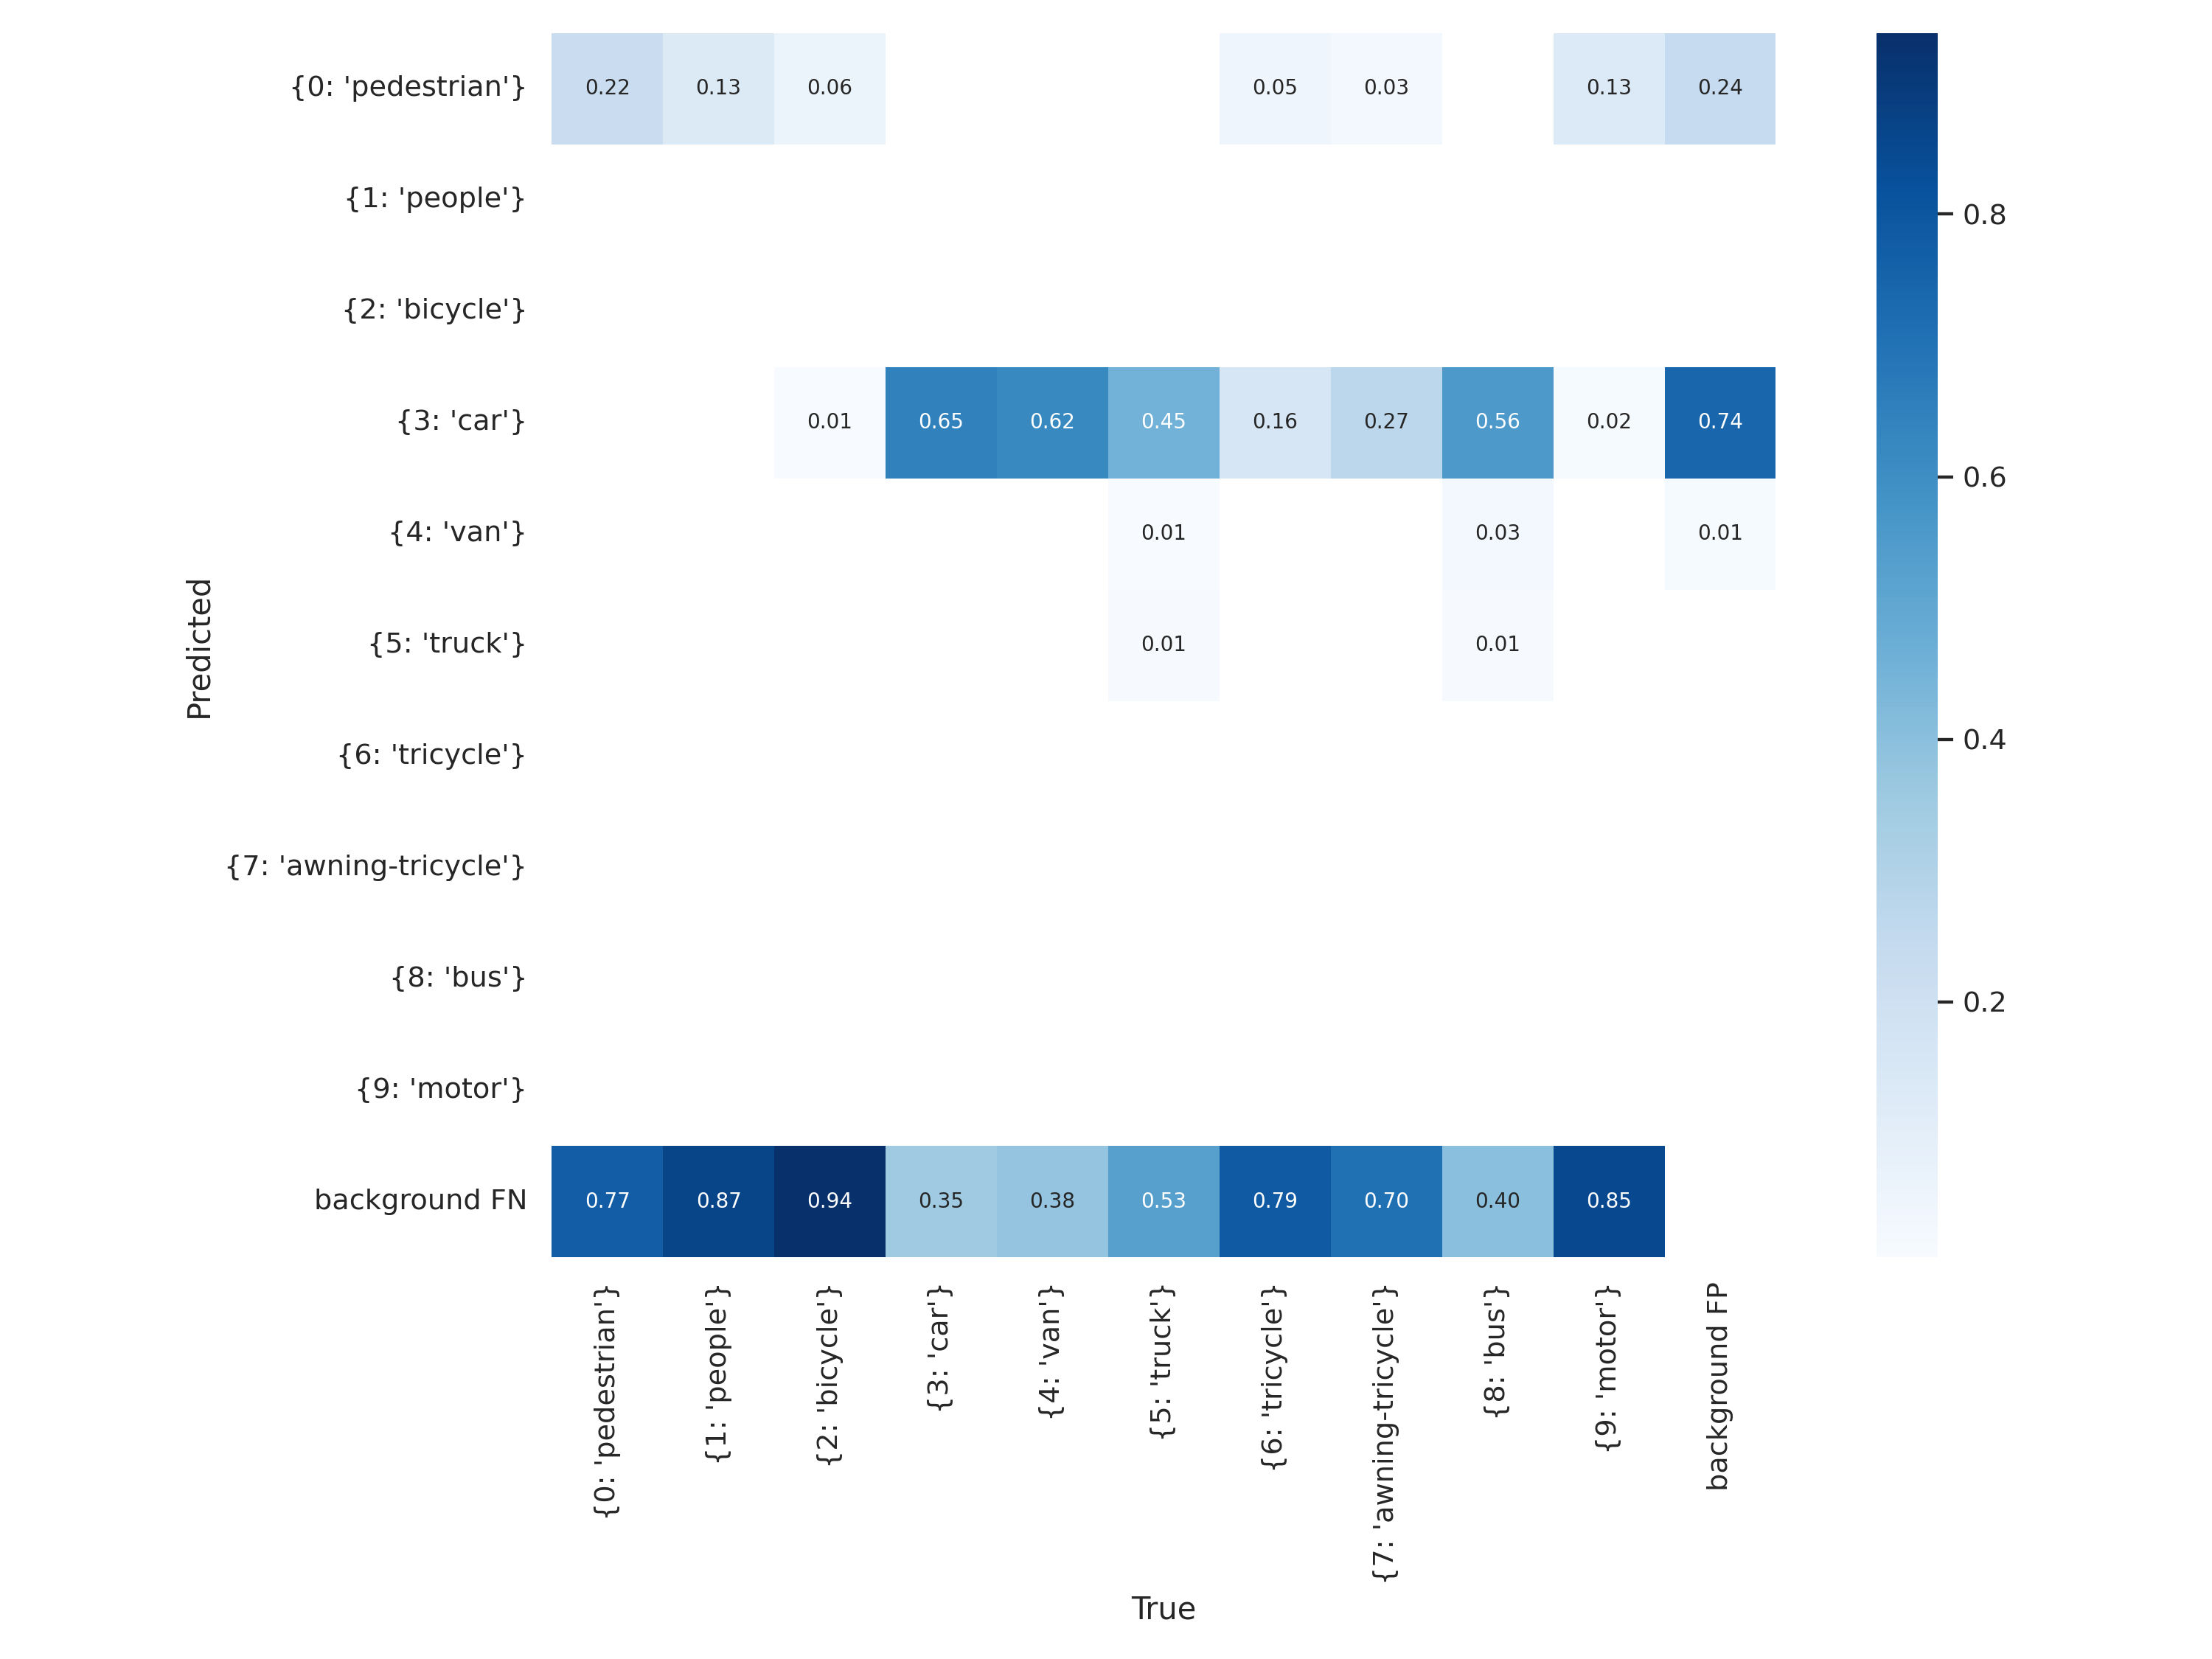

In [96]:
from IPython.display import Image, display

display(Image('/content/tph-yolov5/runs/val/demo/confusion_matrix.png'))
#display(Image('/content/tph-yolov5/runs/val/visdrone_tph-yolov5/confusion_matrix.png'))

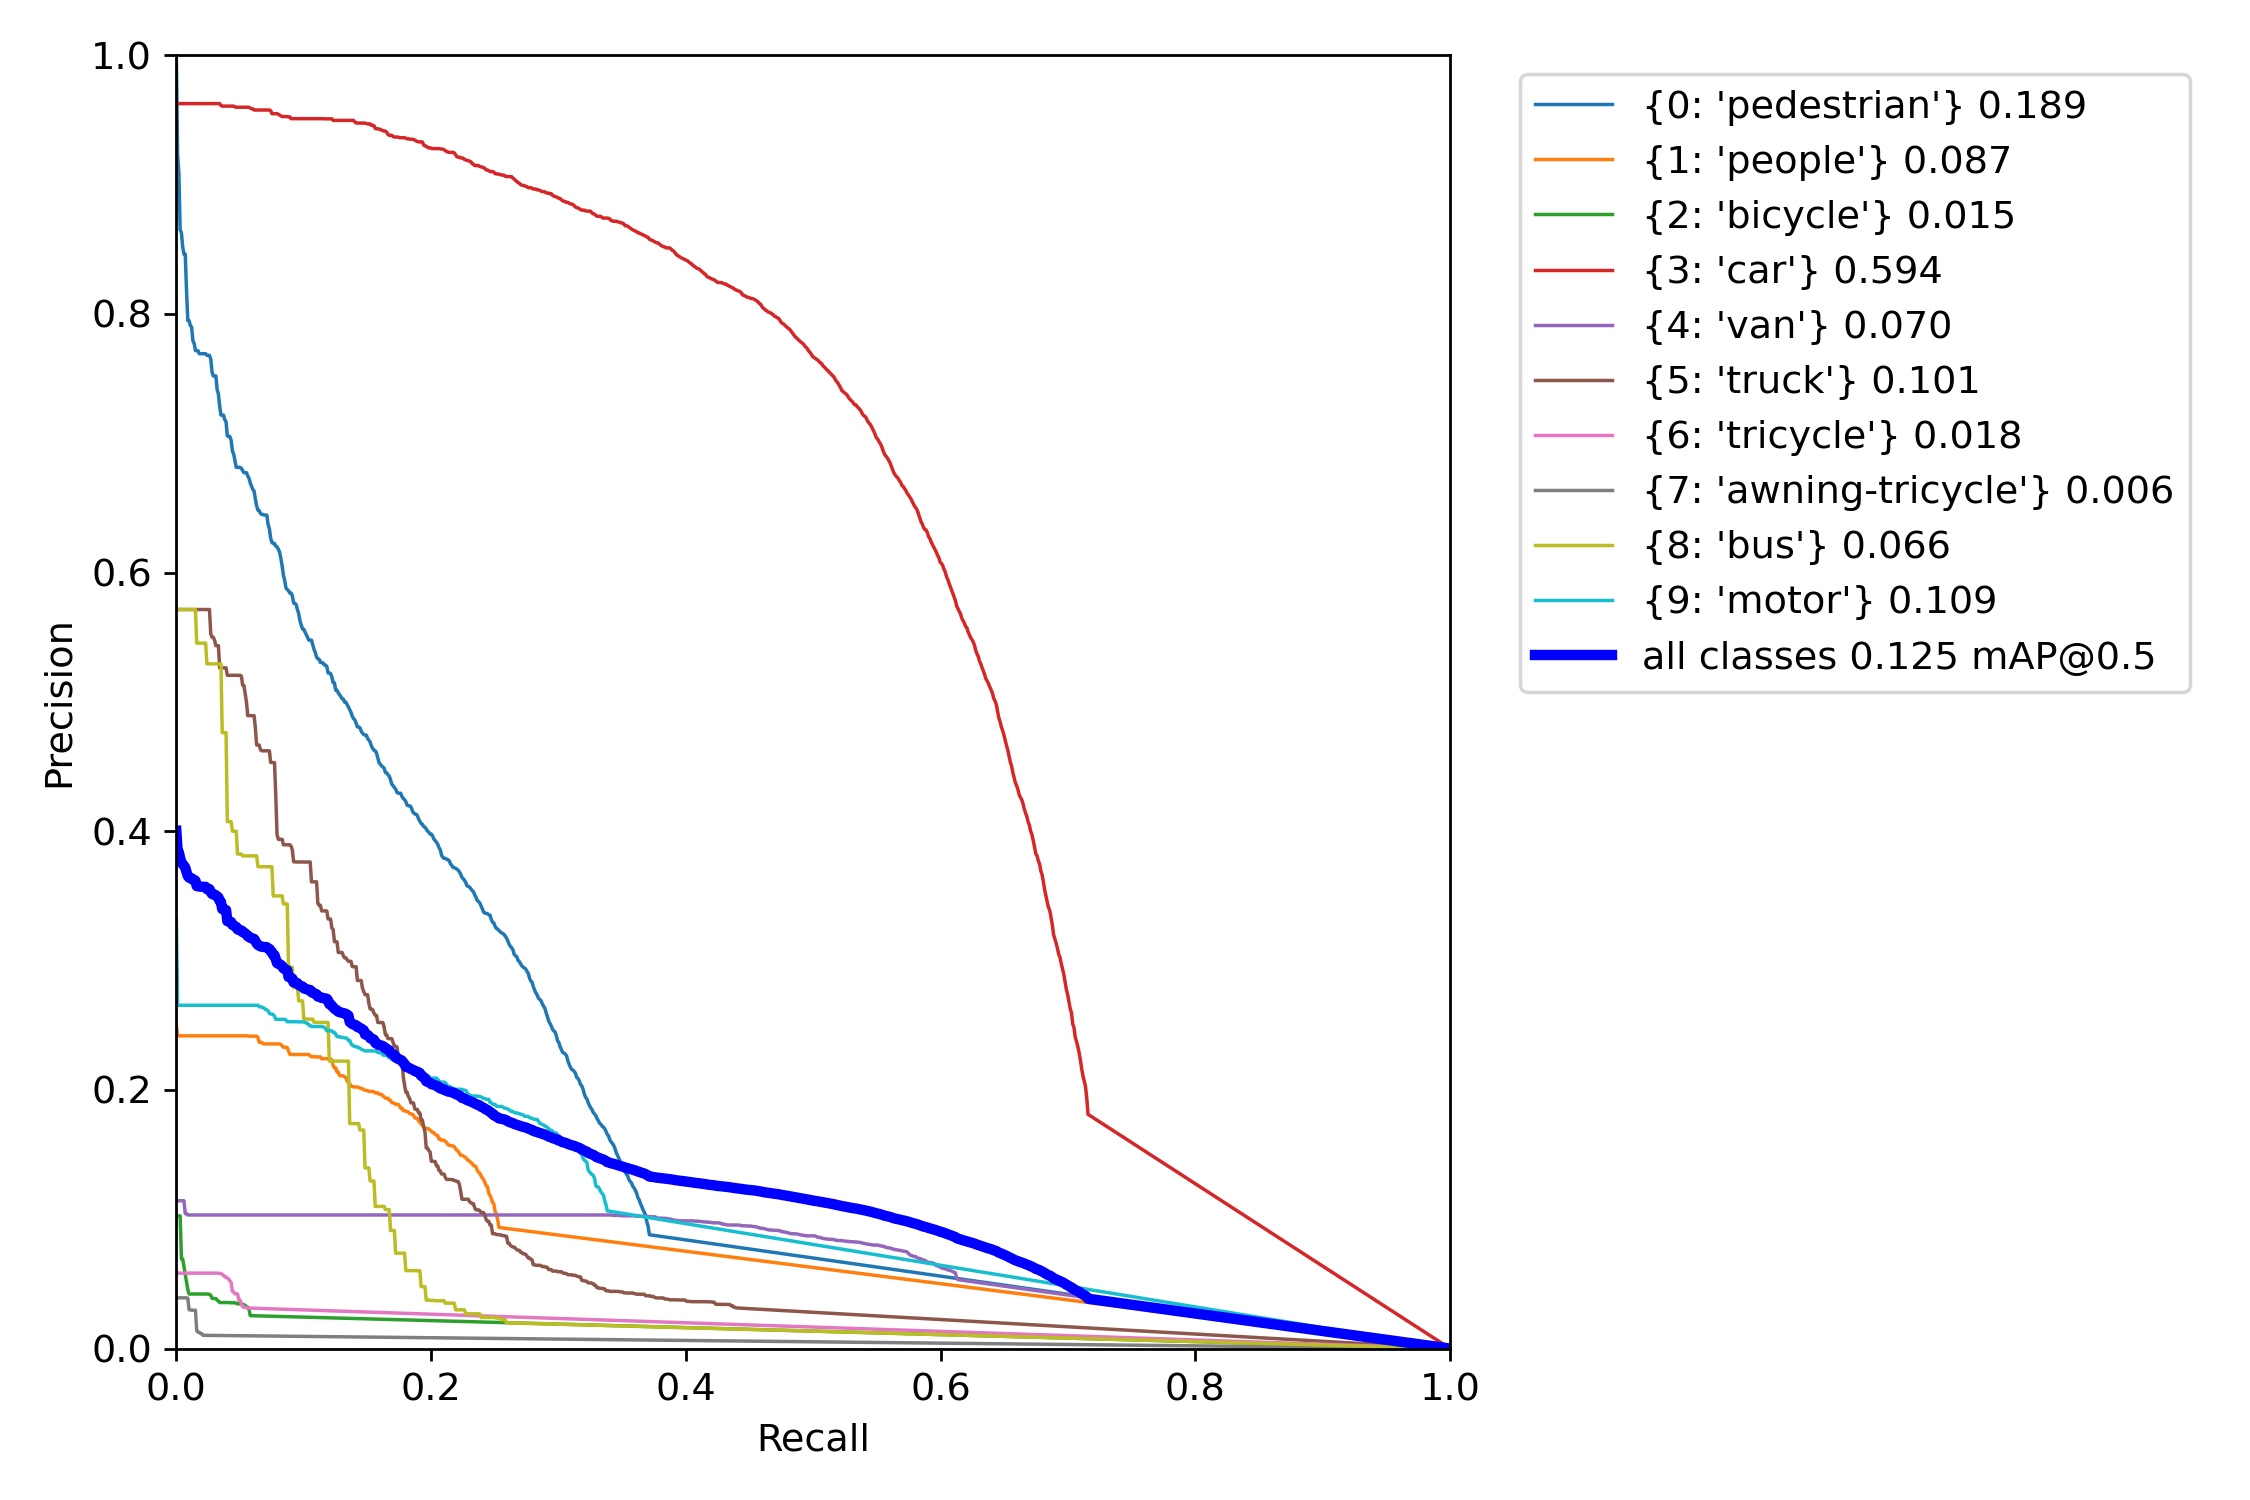

In [106]:
display(Image('/content/tph-yolov5/runs/val/demo/PR_curve.png'))
#display(Image('/content/yolov5/runs/val/visdrone_tph-yolov5/PR_curve.png'))

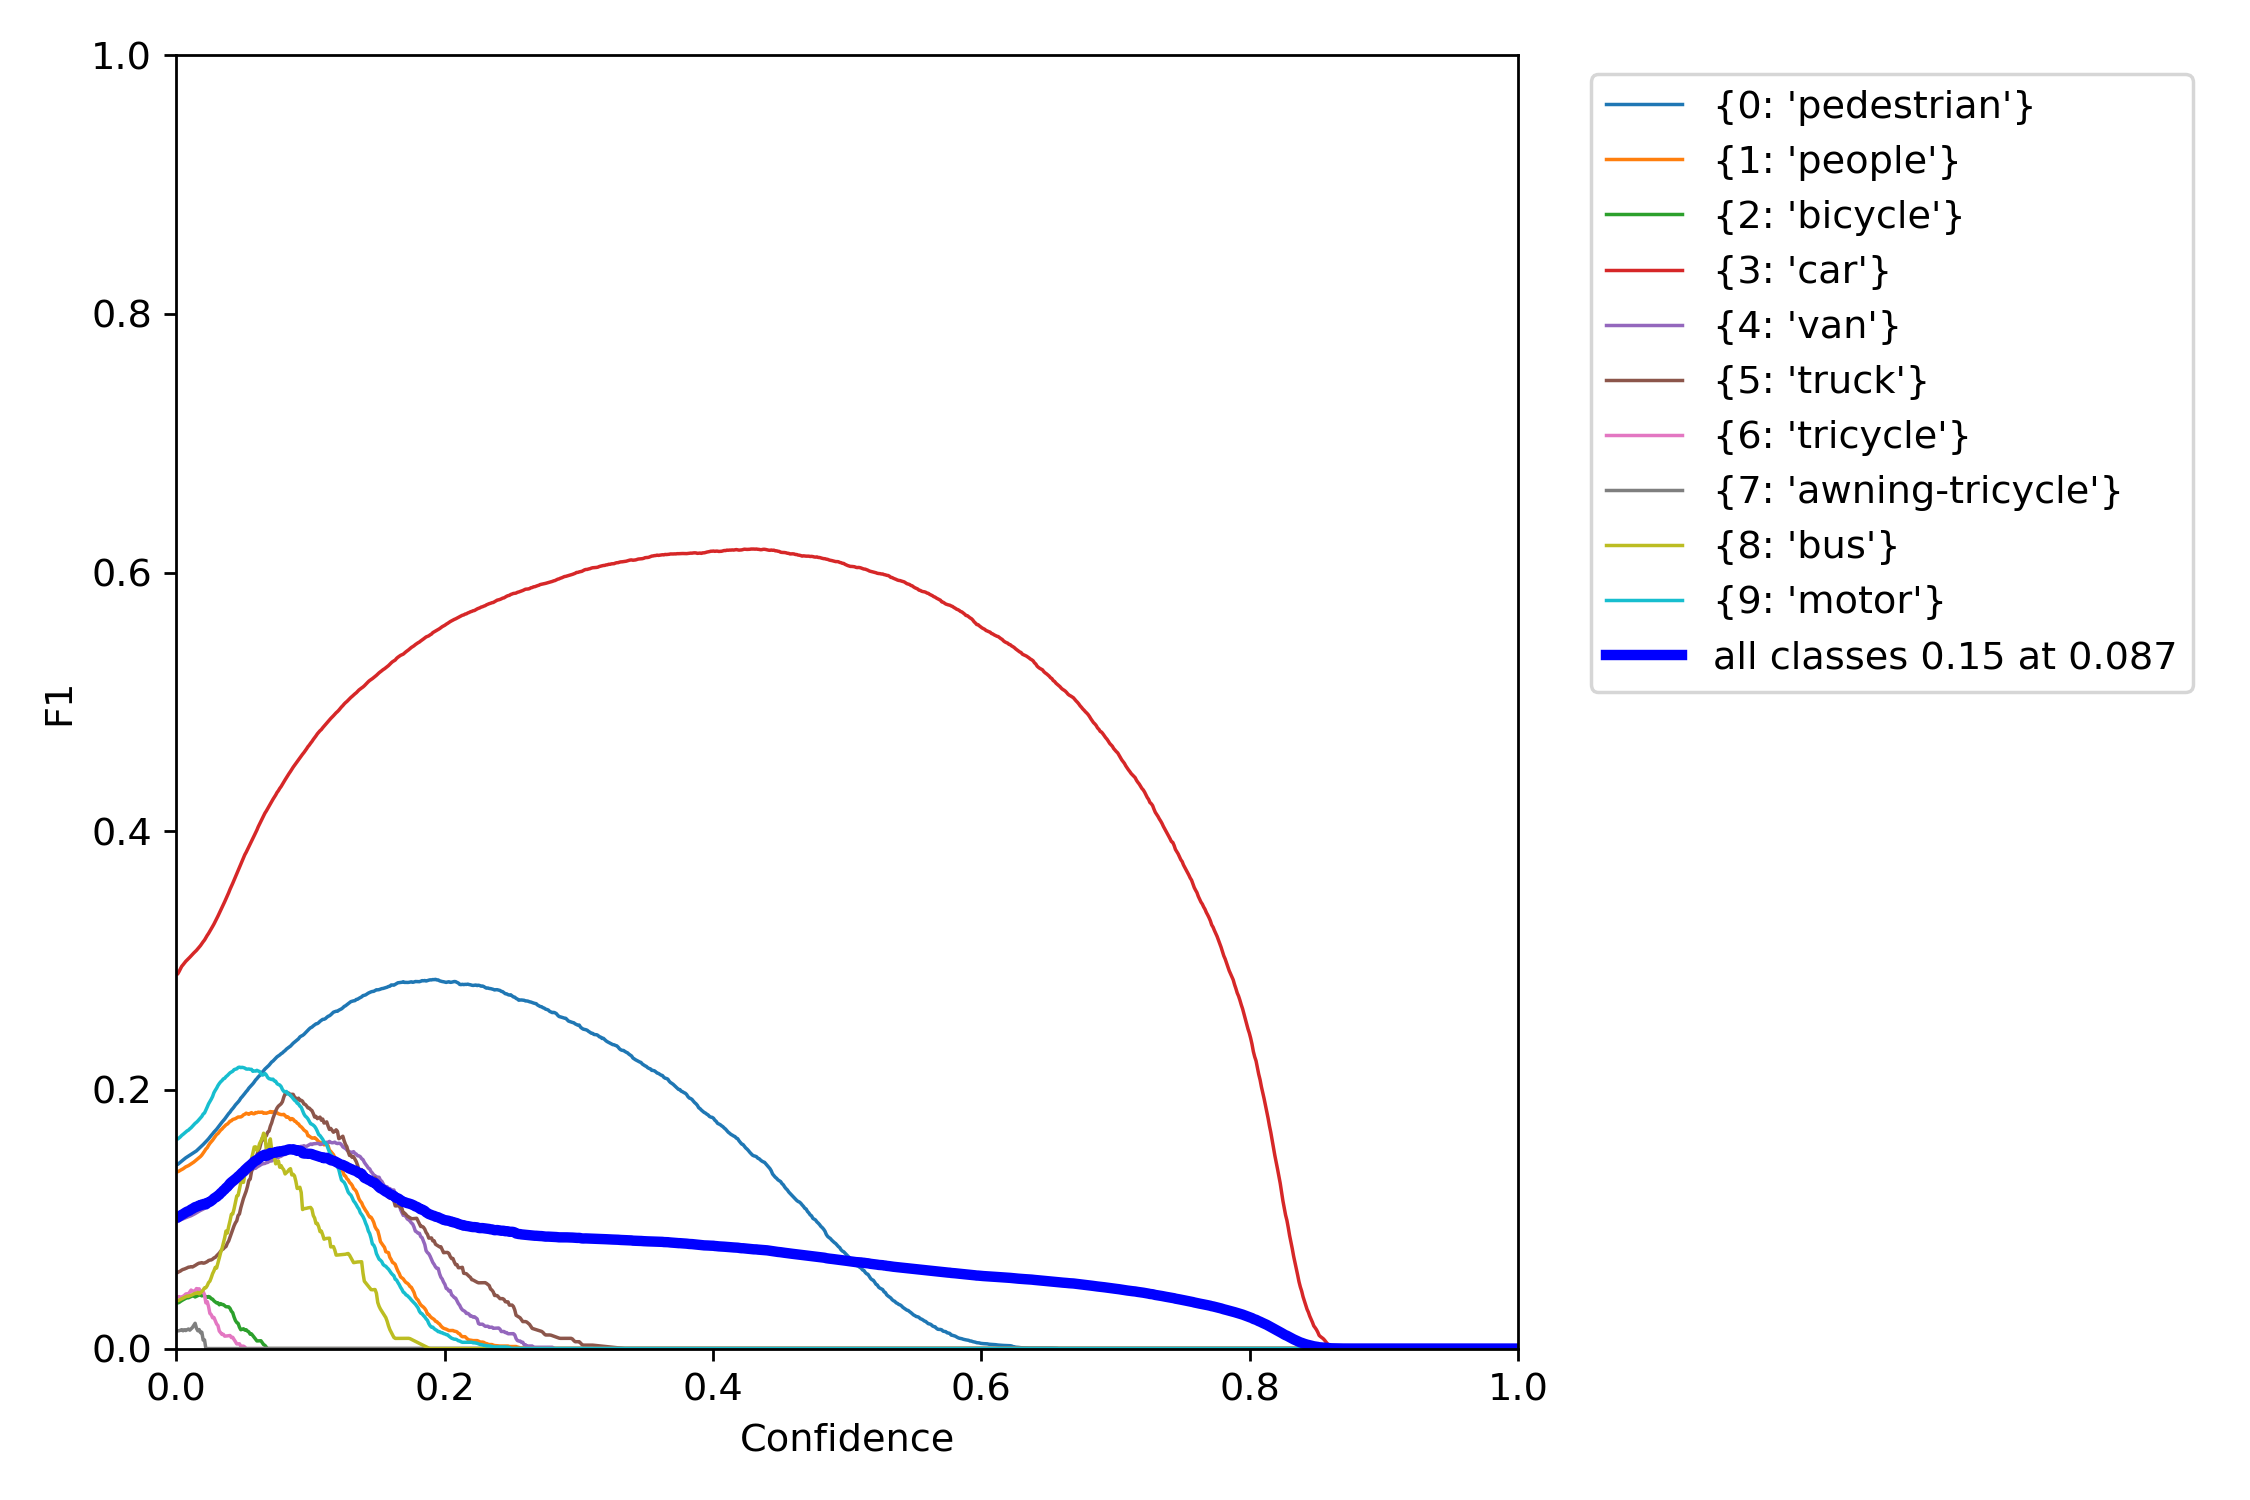

In [107]:
display(Image('/content/tph-yolov5/runs/val/demo/F1_curve.png'))
#display(Image('/content/tph-yolov5/runs/val/visdrone_tph-yolov5/F1_curve.png'))

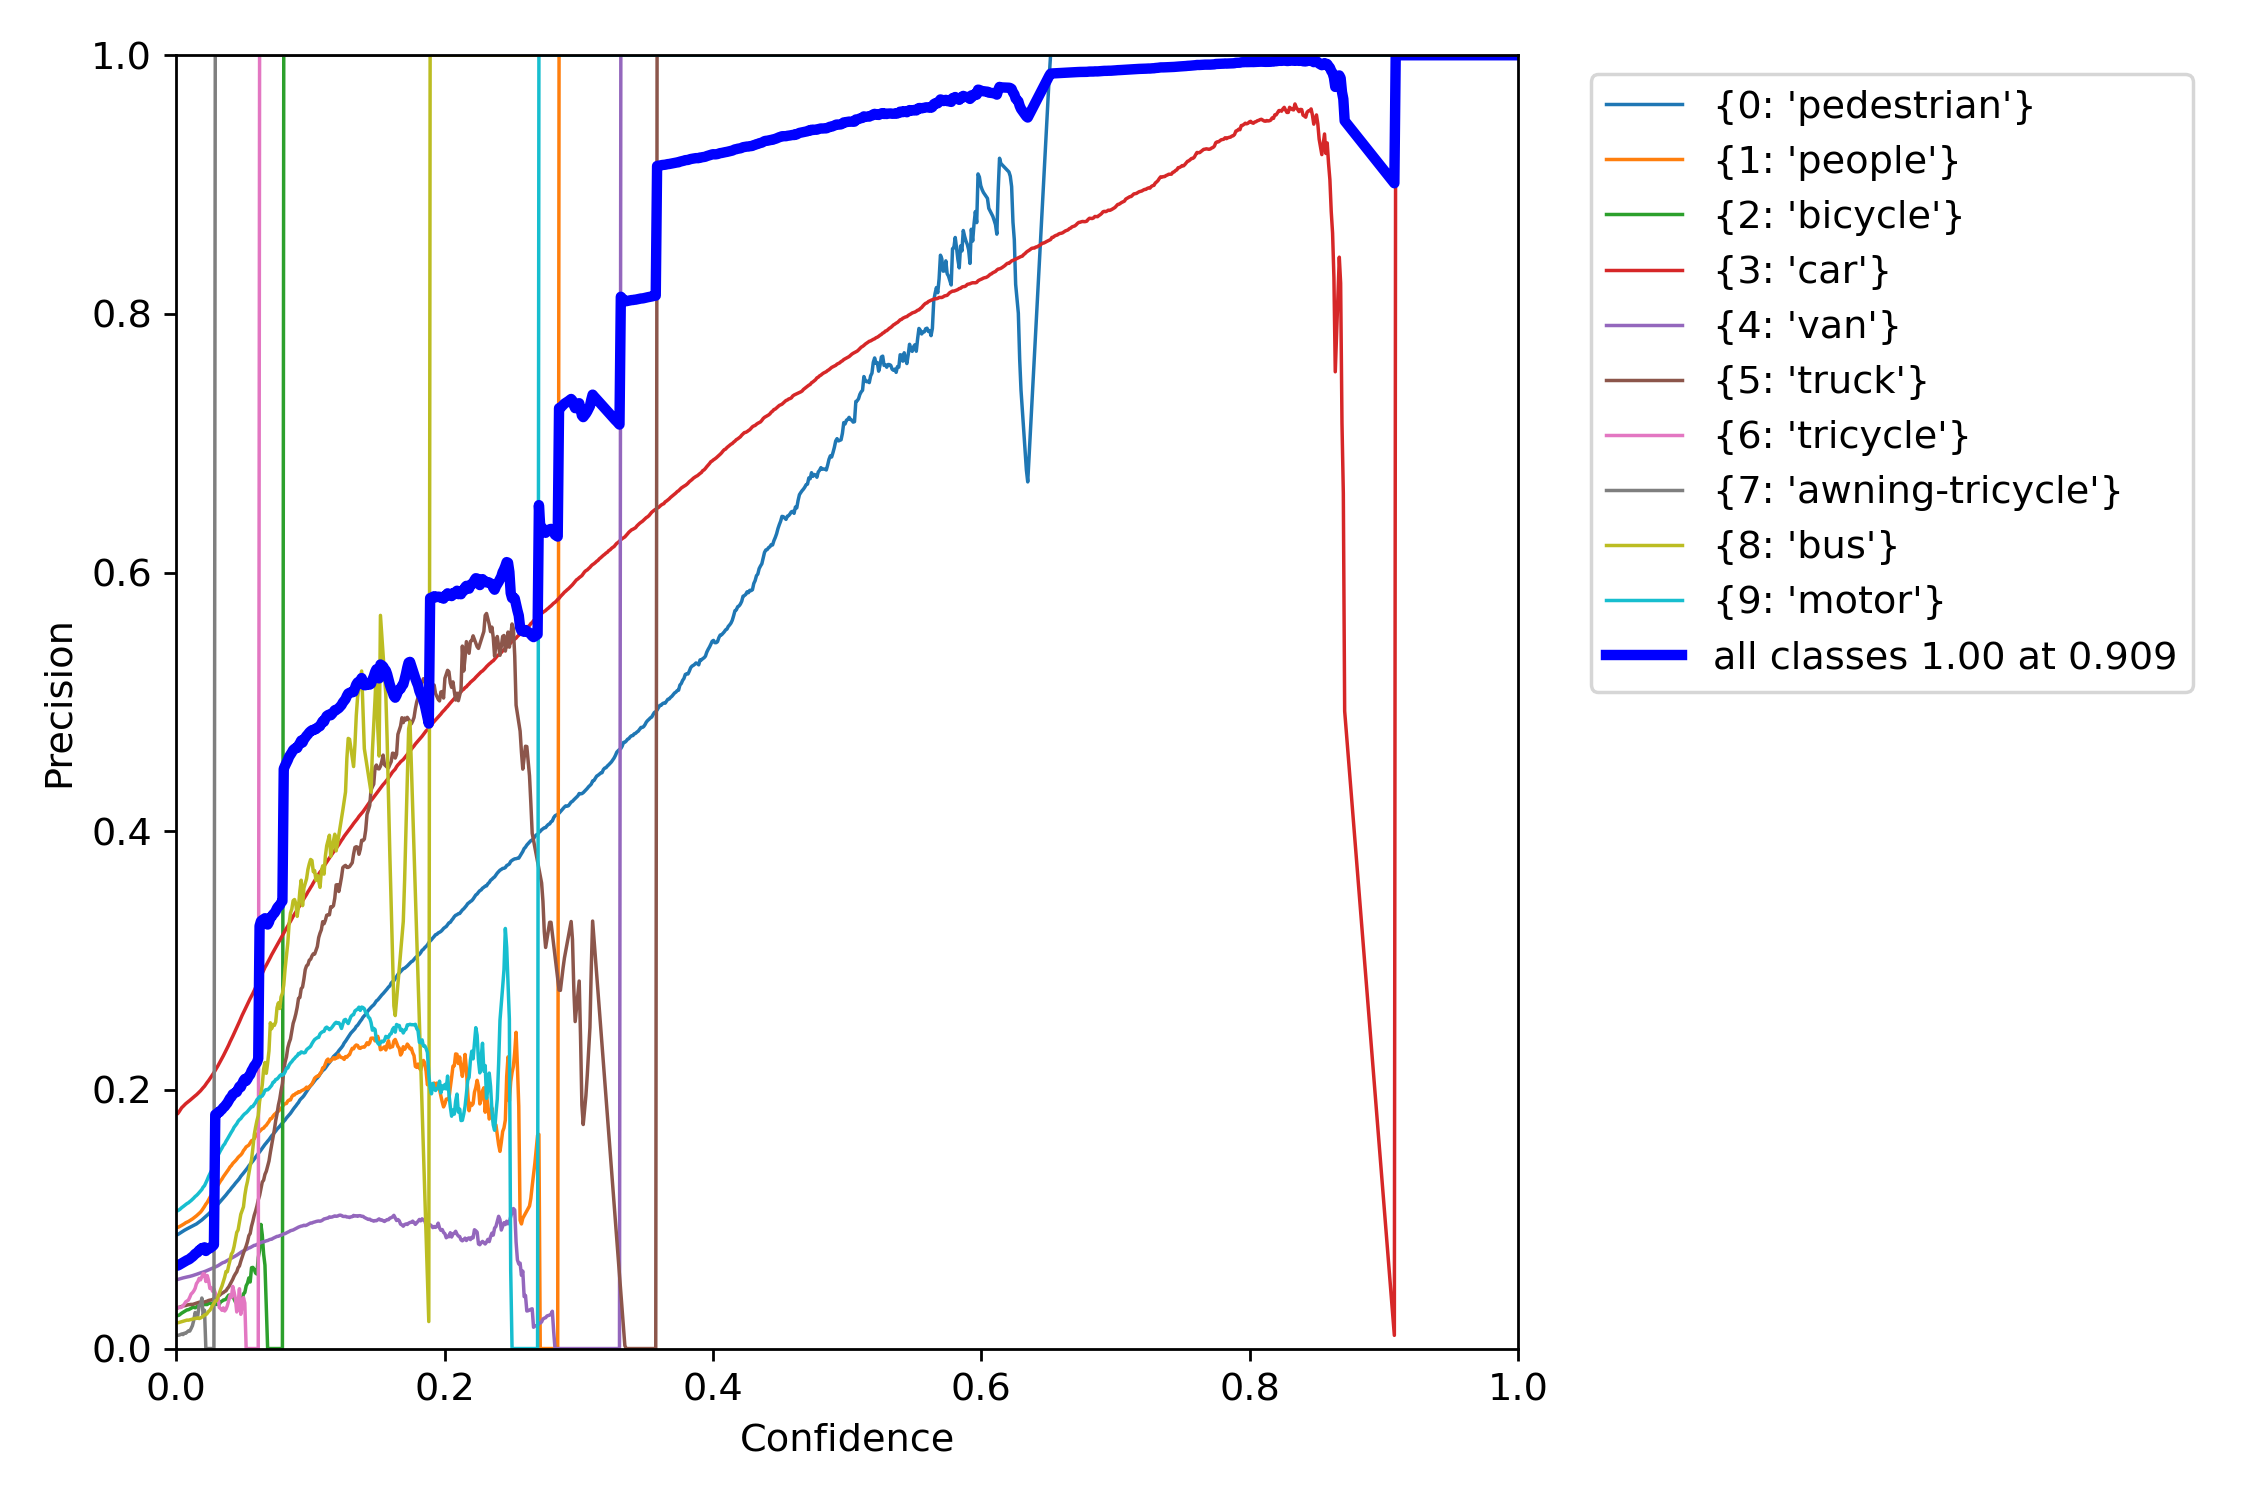

In [108]:
display(Image('/content/tph-yolov5/runs/val/demo/P_curve.png'))
#display(Image('/content/tph-yolov5/runs/val/visdrone_tph-yolov5/P_curve.png'))

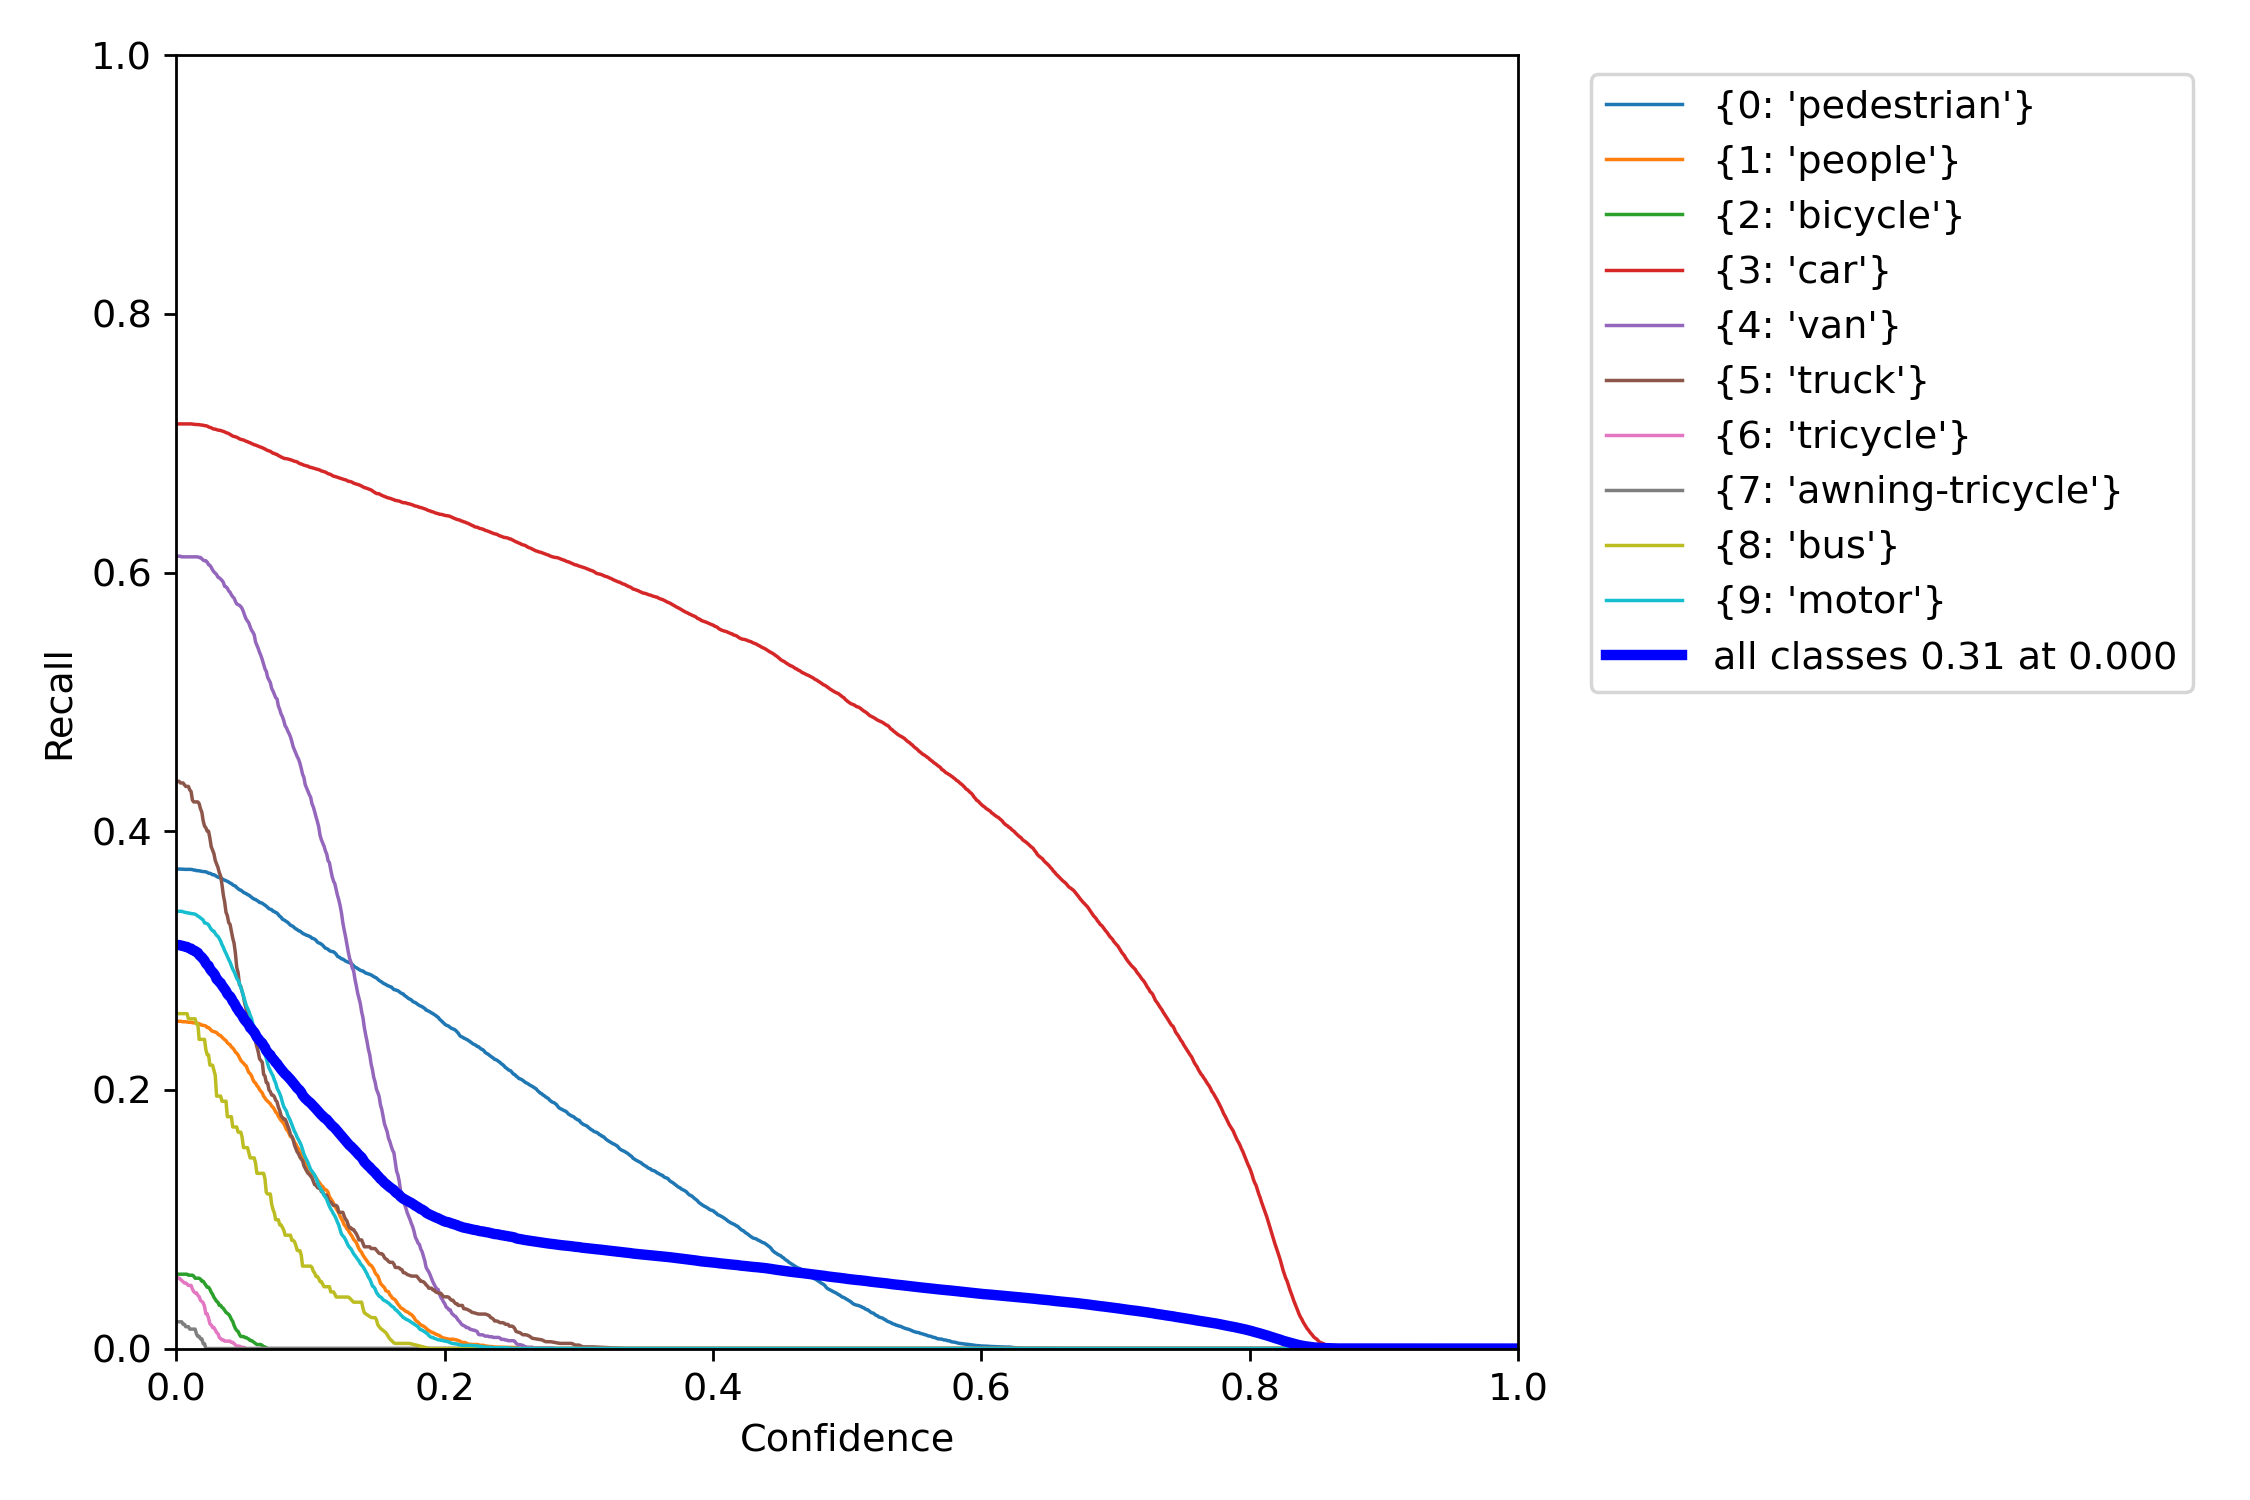

In [109]:
display(Image('/content/tph-yolov5/runs/val/demo/R_curve.png'))
#display(Image('/content/tph-yolov5/runs/val/visdrone_tph-yolov5/R_curve.png')) #mAP, feature maps, saliency maps

In [105]:
!ls /content/datasets/VisDrone/images/test

0000006_00159_d_0000001.jpg  9999944_00000_d_0000003.jpg
0000006_00611_d_0000002.jpg  9999944_00000_d_0000004.jpg
0000006_01111_d_0000003.jpg  9999947_00000_d_0000001.jpg
0000006_01275_d_0000004.jpg  9999947_00000_d_0000002.jpg
0000006_01659_d_0000004.jpg  9999947_00000_d_0000003.jpg
0000006_02138_d_0000006.jpg  9999947_00000_d_0000004.jpg
0000006_02616_d_0000007.jpg  9999947_00000_d_0000005.jpg
0000006_03636_d_0000009.jpg  9999947_00000_d_0000006.jpg
0000006_04050_d_0000010.jpg  9999947_00000_d_0000007.jpg
0000006_04309_d_0000011.jpg  9999947_00000_d_0000008.jpg
0000006_05168_d_0000013.jpg  9999947_00000_d_0000009.jpg
0000006_05208_d_0000014.jpg  9999947_00000_d_0000010.jpg
0000006_05575_d_0000016.jpg  9999947_00000_d_0000011.jpg
0000006_05999_d_0000017.jpg  9999947_00000_d_0000012.jpg
0000006_06773_d_0000018.jpg  9999947_00000_d_0000013.jpg
0000006_07596_d_0000020.jpg  9999947_00000_d_0000014.jpg
0000011_00234_d_0000001.jpg  9999947_00000_d_0000015.jpg
0000011_01350_d_0000003.jpg  99

In [114]:
!ls /content/tph-yolov5/runs/train/exp12/weights

best.pt  last.pt


In [121]:
import torch
from models.experimental import attempt_load

model = attempt_load('/content/tph-yolov5/runs/train/exp12/weights/best.pt', map_location="cuda:0")  # or your actual path
print(type(model))
print(type(model.model))

<class 'models.yolo.Model'>
<class 'torch.nn.modules.container.Sequential'>


In [122]:
def pick_target_layer(model):
    """
    Handles both possible wrapping depths:
    - model.model.model[-2]  (Model wraps an nn.Sequential further)
    - model.model[-2]        (model.model IS already the nn.Sequential)
    """
    import torch.nn as nn

    inner = model.model
    if isinstance(inner, nn.Sequential):
        target_layer = inner[-2]
    else:
        # inner has its own .model attribute holding the Sequential
        target_layer = inner.model[-2]

    print(f"EigenCAM target layer: {type(target_layer).__name__}")
    return [target_layer]

In [123]:
print(type(model))
print(type(model.model))

<class 'models.yolo.Model'>
<class 'torch.nn.modules.container.Sequential'>


model is a models.yolo.Model, and model.model is already the nn.Sequential of layers — so the correct target layer is model.model[-2], not model.model.model[-2].

In [126]:
#EigenCAM Visualization
#Produces 3 EigenCAM heatmap overlays showing which image regions the tph-yolov5 backbone/neck activates on most strongly.
#pip install grad-cam

import os
import sys
import random
from pathlib import Path

import cv2
import numpy as np
import torch
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

REPO_DIR    = '/content/tph-yolov5'
WEIGHTS     = '/content/tph-yolov5/runs/train/exp12/weights/best.pt' #/content/tph-yolov5/runs/train/visdrone_tph-yolov5/weights/best.pt
VAL_IMG_DIR = '/content/datasets/VisDrone/images/val'     # folder of validation images
IMG_SIZE    = 640
DEVICE      = "cuda:0" if torch.cuda.is_available() else "cpu"
N_SAMPLES   = 3
SEED        = 0

OUT_DIR = Path('content/tph-yolov5/eval_outputs/eigencam')
OUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, os.path.abspath(REPO_DIR))
from models.experimental import attempt_load  # noqa: E402
from utils.augmentations import letterbox      # noqa: E402

def load_model():
    model = attempt_load(WEIGHTS, map_location=DEVICE)  # check utils/experimental.py
    model.eval()
    return model

def pick_target_layer(model):
    """
    The last block before the Detect() head is the conventional choice for YOLOv5 CAM work: it's the deepest feature map that still has spatial
    structure tied to the whole image, right before the multi-scale detection heads split things apart.
    tph-yolov5 inserts an extra TransformerBlock (the 'TPH' part) near the end of the neck -- model.model[-2] still lands on the right spot in the
    stock configs, but if you customized the yaml, print(model.model) once and confirm index -2 is a C3/TransformerBlock, not Detect() itself.
    """
    target_layer = model.model[-2] #target_layer = model.model.model[-2]
    return [target_layer]


def preprocess(img_path, img_size):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_letterboxed = letterbox(img_rgb, img_size, auto=True)[0]

    img_float = img_letterboxed.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img_float).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    return tensor, img_float  # img_float used for the visualization overlay

class DetectWrapper(torch.nn.Module):
    """
    pytorch-grad-cam's base CAM class assumes forward() returns a single tensor (like classifier logits), so it can build placeholder target
    categories via argmax. YOLOv5's Model.forward() returns a tuple -- (inference_output, training_output) -- which breaks that assumption.
    This wrapper just unwraps the tuple so grad-cam sees a plain tensor. The target_layer object itself is untouched by this wrapping, since
    forward hooks fire on that module directly regardless of what calls it.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        outputs = self.model(x)
        if isinstance(outputs, (list, tuple)):
            return outputs[0]
        return outputs

def main():
    random.seed(SEED)
    model = load_model()
    target_layers = pick_target_layer(model)

    wrapped_model = DetectWrapper(model)
    cam = EigenCAM(model=wrapped_model, target_layers=target_layers)
    #cam = EigenCAM(model=model, target_layers=target_layers)
    # NOTE: pytorch-grad-cam >=1.4 dropped the `use_cuda` kwarg; device is
    # inferred from the model/input tensors instead.

    all_imgs = sorted(
        p for p in Path(VAL_IMG_DIR).glob("*")
        if p.suffix.lower() in (".jpg", ".jpeg", ".png")
    )
    if len(all_imgs) < N_SAMPLES:
        raise ValueError(f"Only found {len(all_imgs)} images in {VAL_IMG_DIR}")

    samples = random.sample(all_imgs, N_SAMPLES)

    for i, img_path in enumerate(samples, start=1):
        tensor, img_float = preprocess(img_path, IMG_SIZE)

        grayscale_cam = cam(input_tensor=tensor, targets=None)[0, :, :]
        cam_overlay = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

        out_path = OUT_DIR / f"eigencam_sample_{i}.jpg"
        cv2.imwrite(str(out_path), cv2.cvtColor(cam_overlay, cv2.COLOR_RGB2BGR))
        print(f"[ok] {img_path.name} -> {out_path}")


if __name__ == "__main__":
    main()

[ok] 0000313_06601_d_0000469.jpg -> content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_1.jpg
[ok] 0000330_00401_d_0000802.jpg -> content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_2.jpg
[ok] 0000069_01878_d_0000005.jpg -> content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_3.jpg


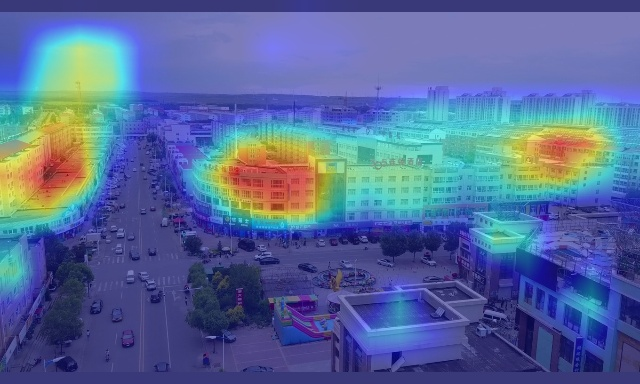

In [127]:
display(Image('content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_1.jpg'))

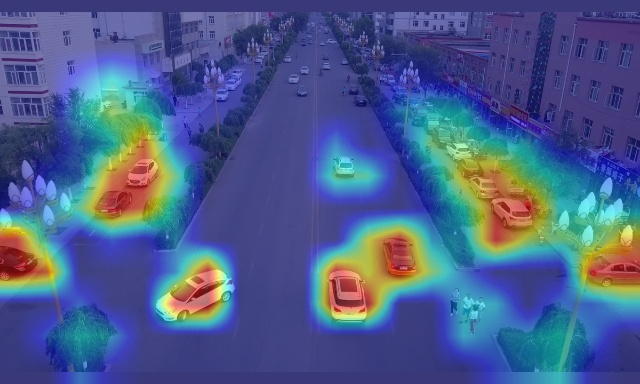

In [128]:
display(Image('content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_2.jpg'))

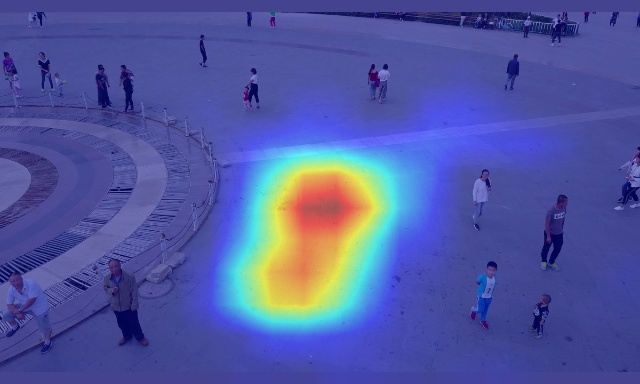

In [129]:
display(Image('content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_3.jpg'))

`pytorch-grad-cam` on YOLO models: the library's base `forward()` assumes the model returns a single tensor (like classifier logits) so it can build placeholder "targets" via `argmax`. YOLOv5's `Model.forward()` returns a **tuple** — `(inference_output, training_output)` — so `.cpu().data.numpy()` fails on the tuple itself.

Fix: wrap the model so its forward pass returns just the tensor part. The target layer stays exactly the same object (`model.model[-2]`),
since forward hooks fire on that layer regardless of what wraps it. (`if isinstance(outputs, tuple): return outputs[0]`).

add the wrapper class, and use it when constructing `EigenCAM`.

the `cam = EigenCAM(...)` line changes to use `wrapped_model` instead of `model`.

Other possible error: the *shape* of `outputs[0]` (YOLO's raw inference tensor is `[batch, num_anchors, no]` rather than `[batch, num_classes]`) — the `argmax`/placeholder-target step will still run but is harmless for EigenCAM specifically, since it doesn't use gradients or those targets for its actual weighting (PCA on activations only).

In [135]:
%%writefile /content/tph-yolov5/03_corruptions.py

"""
03_corruptions.py

Reusable image corruption functions used to build robustness curves. Each function takes a BGR uint8 image (as read by cv2.imread) and a
severity level in {1, 2, 3, 4, 5} (1 = mildest, 5 = harshest), and returns a corrupted BGR uint8 image of the same shape.

Severity 0 is treated as "no corruption" (the original clean image) by the calling script, not by these functions.

These are deliberately simple, dependency-light implementations (numpy + opencv only) so they behave the same regardless of which augmentation
libraries are or aren't installed in your tph-yolov5 environment.
"""

import numpy as np
import cv2

def gaussian_noise(img: np.ndarray, severity: int) -> np.ndarray:
    """Additive Gaussian noise in pixel space. Sigma scales with severity."""
    sigma_levels = {1: 5, 2: 10, 3: 20, 4: 35, 5: 55}
    sigma = sigma_levels[severity]

    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def gaussian_blur(img: np.ndarray, severity: int) -> np.ndarray:
    """Gaussian blur. Kernel size / sigma scale with severity."""
    kernel_levels = {1: 3, 2: 5, 3: 9, 4: 13, 5: 19}
    k = kernel_levels[severity]
    return cv2.GaussianBlur(img, (k, k), sigmaX=0)

def brightness(img: np.ndarray, severity: int, direction: str = "darken") -> np.ndarray:
    """
    Brightness shift via the HSV V-channel.
    direction="darken" simulates dusk/underexposure (the more common failure
    mode for aerial/drone imagery, which is tph-yolov5's usual domain);
    pass direction="brighten" if you want overexposure instead.
    """
    factor_levels = {1: 0.85, 2: 0.70, 3: 0.55, 4: 0.40, 5: 0.25}
    factor = factor_levels[severity]
    if direction == "brighten":
        factor = 1 + (1 - factor)  # e.g. 0.85 -> 1.15, 0.25 -> 1.75

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def occlusion(img: np.ndarray, severity: int, seed: int = None) -> np.ndarray:
    """
    Random rectangular occlusions (gray boxes) covering an increasing
    fraction of the image area. Boxes are placed at random, non-guaranteed
    non-overlapping positions -- at high severities some overlap is expected
    and realistic (mimics heavy clutter/obstruction).
    """
    area_frac_levels = {1: 0.03, 2: 0.07, 3: 0.12, 4: 0.20, 5: 0.30}
    area_frac = area_frac_levels[severity]
    n_boxes = severity + 1  # more, smaller boxes at higher severity

    rng = np.random.default_rng(seed)
    out = img.copy()
    h, w = img.shape[:2]
    total_area = h * w
    target_area_per_box = (total_area * area_frac) / n_boxes

    for _ in range(n_boxes):
        box_w = int(np.sqrt(target_area_per_box * rng.uniform(0.5, 2.0)))
        box_h = int(target_area_per_box / max(box_w, 1))
        box_w, box_h = min(box_w, w), min(box_h, h)

        x0 = rng.integers(0, max(w - box_w, 1))
        y0 = rng.integers(0, max(h - box_h, 1))
        gray_value = int(rng.integers(80, 160))  # mid-gray occluder
        out[y0:y0 + box_h, x0:x0 + box_w] = gray_value

    return out

CORRUPTIONS = {
    "gaussian_noise": gaussian_noise,
    "gaussian_blur": gaussian_blur,
    "brightness": brightness,
    "occlusion": occlusion,
}

Writing /content/tph-yolov5/03_corruptions.py


In [133]:
%%writefile /content/tph-yolov5/04_robustness_evaluation.py

"""
04_robustness_evaluation.py

For each corruption type (gaussian_noise, gaussian_blur, brightness, occlusion) and severity level (0 = clean, 1..5 = increasing severity):

  1. Builds a corrupted copy of the validation image set.
  2. Points a temporary data.yaml at it (labels are symlinked, unchanged,
     since corruptions here don't move objects around).
  3. Runs tph-yolov5's own val.py evaluation to get mAP@0.5 and
     mAP@0.5:0.95, exactly as your training pipeline computes them.
  4. Collects everything into one long-form table.

Then produces:
  - 4 robustness plots (mAP vs. severity), one per corruption type
  - one CSV + one Markdown summary table (mAP@0.5 by corruption x severity)

This is the slow script (it re-runs validation 4 corruptions x 6 severities = 24 times, plus one shared clean baseline = 21 actual runs).
Expect this to take roughly 21x as long as a single val.py call on your dataset.
"""

import os
import sys
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
# Module names can't start with a digit for a normal `import`, so
# 03_corruptions.py is loaded explicitly by file path instead:
import importlib.util
_spec = importlib.util.spec_from_file_location(
    "corruptions", Path(__file__).parent / "03_corruptions.py"
)
corruptions_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(corruptions_mod)
CORRUPTIONS = corruptions_mod.CORRUPTIONS

REPO_DIR    = '/content/tph-yolov5'
WEIGHTS     = '/content/tph-yolov5/runs/train/exp12/weights/best.pt' #/content/tph-yolov5/runs/train/visdrone_tph-yolov5/weights/best.pt
ORIG_DATA_YAML = '/content/tph-yolov5/data/visdrone.yaml'
VAL_IMG_DIR = '/content/datasets/VisDrone/images/val'     # must match the "images" folder data.yaml's val: points to
VAL_LBL_DIR    = '/content/datasets/VisDrone/labels/val'     # sibling "labels" folder, standard YOLO layout
IMG_SIZE    = 640
DEVICE      = "0" #"cuda:0" if torch.cuda.is_available() else "cpu"
BATCH_SIZE     = 16
CONF_THRES     = 0.001
IOU_THRES      = 0.6
SEVERITIES     = [0, 1, 2, 3, 4, 5]      # 0 = clean baseline

TMP_ROOT = Path("./tmp_corrupted")
OUT_DIR  = Path('/content/tph-yolov5/eval_outputs/robustness')
OUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, os.path.abspath(REPO_DIR))
import val as tph_val  # noqa: E402

if not labels_out.exists():
    os.symlink(Path(VAL_LBL_DIR).resolve(), labels_out)

def build_corrupted_dataset(name: str, severity: int) -> Path:
    """
    Returns a path to a data.yaml for this (corruption, severity) pair.
    Severity 0 just returns the original data.yaml -- no copying needed.
    """
    if severity == 0:
        return Path(ORIG_DATA_YAML)

    base = TMP_ROOT / f"{name}_sev{severity}"
    images_out = base / "images" / "val"
    labels_out = base / "labels" / "val"
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.parent.mkdir(parents=True, exist_ok=True)   # <-- add this line

    if not labels_out.exists():
        # These corruptions don't move/remove objects, so ground truth boxes
        # are untouched -- we just symlink the labels folder in at the
        # standard YOLO path (images/val -> labels/val) rather than copying.
        os.symlink(Path(VAL_LBL_DIR).resolve(), labels_out)

    corrupt_fn = CORRUPTIONS[name]
    src_images = sorted(
        p for p in Path(VAL_IMG_DIR).glob("*")
        if p.suffix.lower() in (".jpg", ".jpeg", ".png")
    )
    for img_path in src_images:
        out_path = images_out / img_path.name
        if out_path.exists():
            continue  # already generated in a previous run
        img = cv2.imread(str(img_path))
        corrupted = corrupt_fn(img, severity)
        cv2.imwrite(str(out_path), corrupted)

    # Build a data.yaml identical to the original but pointing val: here
    with open(ORIG_DATA_YAML) as f:
        data_cfg = yaml.safe_load(f)
    data_cfg["val"] = str(images_out.resolve())
    tmp_yaml_path = base / "data.yaml"
    with open(tmp_yaml_path, "w") as f:
        yaml.safe_dump(data_cfg, f)

    return tmp_yaml_path


def evaluate(data_yaml_path: Path, run_name: str):
    results = tph_val.run(
        data=str(data_yaml_path),
        weights=WEIGHTS,
        batch_size=BATCH_SIZE,
        imgsz=IMG_SIZE,
        conf_thres=CONF_THRES,
        iou_thres=IOU_THRES,
        device=DEVICE,
        save_json=False,
        plots=False,
        project=str(OUT_DIR / "runs"),
        name=run_name,
        exist_ok=True,
        task="val",
    )
    # tph-yolov5's val.run returns something like:
    # (mp, mr, map50, map, box_loss, obj_loss, cls_loss), maps, t
    # >>> ADAPT: if your fork's return signature differs, adjust the
    # unpacking below (print(results) once to check order/shape).
    metrics = results[0]
    mp, mr, map50, map_5095 = metrics[0], metrics[1], metrics[2], metrics[3]
    return {"precision": mp, "recall": mr, "mAP50": map50, "mAP50_95": map_5095}


def main():
    rows = []

    # Run the clean baseline once and reuse it for every corruption type's
    # severity-0 point.
    print("=== Clean baseline (severity 0) ===")
    baseline = evaluate(Path(ORIG_DATA_YAML), "clean_baseline")
    for name in CORRUPTIONS:
        rows.append({"corruption": name, "severity": 0, **baseline})

    for name in CORRUPTIONS:
        for sev in tqdm([s for s in SEVERITIES if s != 0], desc=name):
            data_yaml_path = build_corrupted_dataset(name, sev)
            metrics = evaluate(data_yaml_path, f"{name}_sev{sev}")
            rows.append({"corruption": name, "severity": sev, **metrics})

    df = pd.DataFrame(rows).sort_values(["corruption", "severity"])
    df.to_csv(OUT_DIR / "mAP_results_long.csv", index=False)

    # --- Individual robustness plots -------------------------------------
    for name in CORRUPTIONS:
        sub = df[df["corruption"] == name].sort_values("severity")
        plt.figure(figsize=(6, 4.5))
        plt.plot(sub["severity"], sub["mAP50"], marker="o", label="mAP@0.5")
        plt.plot(sub["severity"], sub["mAP50_95"], marker="s", label="mAP@0.5:0.95")
        plt.xlabel("Corruption severity")
        plt.ylabel("mAP")
        plt.title(f"tph-yolov5 robustness: {name.replace('_', ' ').title()}")
        plt.xticks(SEVERITIES)
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        out_path = OUT_DIR / f"{name}_robustness.png"
        plt.savefig(out_path, dpi=150)
        plt.close()
        print(f"[ok] {out_path}")

    # --- Summary table (mAP@0.5, corruption x severity) -------------------
    pivot_50 = df.pivot(index="corruption", columns="severity", values="mAP50")
    pivot_50.columns = [f"severity_{c}" for c in pivot_50.columns]
    pivot_50.to_csv(OUT_DIR / "mAP_summary_table.csv")

    with open(OUT_DIR / "mAP_summary_table.md", "w") as f:
        f.write("# mAP@0.5 by corruption type and severity\n\n")
        f.write(pivot_50.round(4).to_markdown())
        f.write("\n\n# mAP@0.5:0.95 by corruption type and severity\n\n")
        pivot_5095 = df.pivot(index="corruption", columns="severity", values="mAP50_95")
        pivot_5095.columns = [f"severity_{c}" for c in pivot_5095.columns]
        f.write(pivot_5095.round(4).to_markdown())

    print(f"\n[ok] Summary tables written to {OUT_DIR}/mAP_summary_table.{{csv,md}}")
    print(pivot_50.round(4))


if __name__ == "__main__":
    main()

Writing /content/tph-yolov5/04_robustness_evaluation.py


In [141]:
!python 04_robustness_evaluation.py

=== Clean baseline (severity 0) ===
YOLOv5 🚀 052dfeb torch 2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model Summary: 367 layers, 46156743 parameters, 0 gradients, 107.8 GFLOPs
val: Scanning '/content/datasets/VisDrone/labels/val.cache' images and labels... 548 found, 0 missing, 0 empty, 0 corrupted: 100% 548/548 [00:00<?, ?it/s]
               Class     Images     Labels          P          R     mAP@.5 mAP@.5:.95: 100% 35/35 [00:15<00:00,  2.24it/s]
                 all        548      38759      0.463      0.206      0.125     0.0591
   {0: 'pedestrian'}        548       8844      0.185      0.326      0.189     0.0645
       {1: 'people'}        548       5125      0.196      0.162     0.0866     0.0241
      {2: 'bicycle'}        548       1287          1          0     0.0145    0.00338
          {3: 'car'}        548      14064      0.334      0.686      0.594      0.326
          {4: 'van'}        548       1975     0.0917      0.465     0.0695     0.0369
      

In [140]:
import os
print(os.path.exists("/content/datasets/VisDrone/labels/val"))
print(os.path.exists("/content/datasets/VisDrone/images/val"))

True
True


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('/content/tph-yolov5/robustness_results', 'zip', '/content/tph-yolov5/eval_outputs/robustness')
files.download('/content/tph-yolov5/robustness_results.zip')

In [ ]:
#For the 4 plots you already generated as PNGs
from IPython.display import Image, display

for name in ["gaussian_noise", "gaussian_blur", "brightness", "occlusion"]:
    display(Image(f"eval_outputs/robustness/{name}_robustness.png"))

In [ ]:
#For the summary table, load it back as a DataFrame so it renders as a proper table (nicer than reading raw CSV text):
import pandas as pd

df = pd.read_csv("eval_outputs/robustness/mAP_summary_table.csv", index_col=0)
df  # in a Colab cell, just having this as the last line renders it as a table

In [ ]:
#all 4 plots side-by-side in one grid instead of stacked one after another
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
names = ["gaussian_noise", "gaussian_blur", "brightness", "occlusion"]

for ax, name in zip(axes.flat, names):
    img = mpimg.imread(f"eval_outputs/robustness/{name}_robustness.png")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(name.replace("_", " ").title())

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download('/content/tph-yolov5/runs/val/demo/confusion_matrix.png')
files.download('/content/tph-yolov5/runs/val/demo/F1_curve.png')
files.download('/content/tph-yolov5/runs/val/demo/PR_curve.png')
files.download('/content/tph-yolov5/runs/val/demo/P_curve.png')
files.download('/content/tph-yolov5/runs/val/demo/R_curve.png')
files.download('/content/datasets/VisDrone/images/val/0000313_06601_d_0000469.jpg')
files.download('/content/datasets/VisDrone/images/val/0000330_00401_d_0000802.jpg')
files.download('/content/datasets/VisDrone/images/val/0000069_01878_d_0000005.jpg')
files.download('/content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_1.jpg')
files.download('/content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_2.jpg')
files.download('/content/tph-yolov5/eval_outputs/eigencam/eigencam_sample_3.jpg')